# ISEF Results Notebook — Predicting Kelp Forest Regime Shifts
## Tony Lin

**Hypothesis:** If a model integrates early warning signals (EWS) with environmental drivers, it will predict catastrophic regime shifts in kelp canopy biomass, because EWS metrics detect the critical slowing down that occurs when environmental stressors push the ecosystem toward a tipping point.

---

### Notebook Structure
| Section | Slide | Content |
|---------|-------|---------|
| Cells 1–3 | Setup | Imports, data loading, methodology definitions |
| Cells 4–7 | Slide 7 | EWS detection: figures + statistical tables |
| Cells 8–11 | Slide 8 | ML performance: figures + statistical tables |
| Cells 12–15 | Slide 9 | Geographic synthesis: figures + statistical tables |

Run cells in order. All figures save to `../../5_FIGURES/isef_slides/`

In [1]:
# ============================================================
# CELL 1: IMPORTS & SHARED CONFIG
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import mannwhitneyu, kendalltau, linregress, binomtest, wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc as sklearn_auc,
    average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss
)
import warnings
warnings.filterwarnings('ignore')

BASE    = Path('../../1_DATA/processed')
FIG_DIR = Path('../../5_FIGURES/isef_slides')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.4,
    'xtick.major.width': 1.4,
    'ytick.major.width': 1.4,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  '#cccccc',
    'figure.dpi':        150,
})

REGION_COLORS = {'norcal':'#1f77b4','midcal':'#d6604d','socal':'#2ca02c','bigsur':'#9467bd'}
REGION_NAMES  = {'norcal':'Northern CA','midcal':'Central CA','socal':'Southern CA','bigsur':'Big Sur'}
FEATURES = ['ews_composite','heat_lag4','upwelling','heat_x_ews']
TARGET   = 'onset'
REGIONS  = ['norcal','midcal','socal','bigsur']
ROLL_WIN = 20
HEAT_LAG = 4
THRESHOLD = 0.35

print('✓ Config ready. FIG_DIR:', FIG_DIR.resolve())

✓ Config ready. FIG_DIR: /Users/tonylin/Documents/kelp_project/5_FIGURES/isef_slides


---
## Methodology Reference

The cell below documents every key methodological decision in one place. **Judges will ask about these.** Read before presenting.

### How Suppression Was Defined
Raw kelp area is highly seasonal — it peaks in summer and dips in winter every year. Comparing raw values across seasons would label every winter as a "collapse," which is meaningless. To remove this seasonal cycle:

1. **De-seasonalization via robust z-score:** For each calendar quarter (Q1=Feb, Q2=May, Q3=Aug, Q4=Nov), compute the *median* and *MAD* (median absolute deviation) of kelp biomass using only the **1984–2013 baseline period** — before the 2014 marine heatwave ("the Blob") that caused widespread collapse. MAD is used instead of standard deviation because it is resistant to outliers (i.e., the collapse years don't distort the baseline).

   `kelp_q_z = (kelp_smooth − quarterly_median) / quarterly_MAD`

2. **1-year smoothing:** The z-score is then passed through a 4-quarter rolling mean (`kelp_z_1yr`) to capture *sustained* low states, not single noisy quarters.

3. **Suppression threshold:** A quarter is labeled `suppressed = 1` if `kelp_z_1yr` falls below the **10th percentile** of the baseline distribution. This means kelp must be in the bottom 10% of its historical range — not just slightly below average.

4. **Onset detection:** `onset = 1` only at the **0→1 transition** (the first quarter of a new suppression episode). This is much harder to predict than classifying an already-suppressed state, and is what matters ecologically — it tests whether the model can warn *before* collapse begins.

### How EWS Was Computed
Critical Slowing Down (CSD) theory (Dakos et al. 2012) predicts that a system approaching a tipping point will exhibit:
- **Rising lag-1 autocorrelation (AR1):** The system "remembers" its past state longer — slow recovery from small perturbations.
- **Rising variance:** Fluctuations grow larger as stability decreases.

Both are computed in a **20-quarter (5-year) rolling window** on the de-seasonalized kelp z-score. The composite EWS score = (standardized AR1 + standardized variance) / 2.

### Why Block Bootstrap?
Kelp time series are temporally autocorrelated — consecutive quarters are not independent. Standard significance tests (t-test, Fisher's exact) assume independence and would produce falsely narrow confidence intervals. Block bootstrap resamples *blocks* of 4 consecutive quarters at a time, preserving temporal autocorrelation structure. All CIs in this notebook use block bootstrap with 2,000–3,000 resamples.

In [2]:
# ============================================================
# CELL 2: DATA LOADING + FEATURE ENGINEERING
# ============================================================
def load_region(region):
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / region / f'{region}_kelp_sst_labeled.csv',
        BASE / f'{region}_kelp_sst_labeled.csv',
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')
            df['region'] = region
            return df
    raise FileNotFoundError(f'No file found for {region}')

def add_features(df):
    df = df.copy()
    if 'kelp_q_z' not in df.columns:
        col = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
        df['q'] = df.index.quarter
        base = df.loc['1984':'2013']
        med  = base.groupby('q')[col].median()
        mad  = base.groupby('q')[col].apply(lambda x: np.median(np.abs(x-np.median(x)))+1e-9)
        df['kelp_q_z'] = (df[col] - df['q'].map(med)) / df['q'].map(mad)
        df.drop(columns=['q'], inplace=True)
    z   = df['kelp_q_z']
    ar1 = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=True)
    var = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).var()
    df['ar1'] = ar1
    df['variance'] = var
    ar1_z = (ar1-ar1.mean())/ar1.std()
    var_z = (var-var.mean())/var.std()
    df['ews_composite'] = (ar1_z + var_z) / 2
    df['heat_lag4'] = df['sstanom_q_max'].shift(HEAT_LAG)
    up_col = 'uianom_q_mean_lag1' if 'uianom_q_mean_lag1' in df.columns else 'uianom_q_mean'
    df['upwelling'] = df[up_col] if up_col in df.columns else np.nan
    df['heat_x_ews'] = df['heat_lag4'] * df['ews_composite']
    s = df['suppressed'].astype(int)
    df['onset']  = ((s==1) & (s.shift(1)==0)).astype(int)
    df['offset'] = ((s==0) & (s.shift(1)==1)).astype(int)
    return df

print('Loading regions...')
region_dfs = {}
for r in REGIONS:
    try:
        region_dfs[r] = add_features(load_region(r))
        df = region_dfs[r]
        print(f'  ✓ {r}: {len(df)} quarters | {df["onset"].sum()} onset events | '
              f'{df["suppressed"].sum()} suppressed | {df.index.min().year}–{df.index.max().year}')
    except FileNotFoundError as e:
        print(f'  ✗ SKIP: {e}')

print(f'\nLoaded {len(region_dfs)} regions.')

Loading regions...
  ✓ norcal: 152 quarters | 5 onset events | 54 suppressed | 1984–2025
  ✓ midcal: 157 quarters | 4 onset events | 17 suppressed | 1984–2025
  ✓ socal: 167 quarters | 2 onset events | 8 suppressed | 1984–2025
  ✓ bigsur: 158 quarters | 4 onset events | 16 suppressed | 1984–2025

Loaded 4 regions.


In [3]:
# ============================================================
# CELL 3: BLOCK BOOTSTRAP + TABLE STYLING HELPERS
# ============================================================
def block_bootstrap_auc(score, y, block_len=4, B=2000, seed=42):
    score = np.asarray(score, dtype=float)
    y     = np.asarray(y, dtype=int)
    n     = len(y)
    starts   = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng      = np.random.default_rng(seed)
    aucs = []
    for _ in range(B):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx    = np.concatenate([np.arange(s, s+block_len) for s in chosen])[:n]
        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2: continue
        aucs.append(roc_auc_score(yb, sb))
    aucs = np.array(aucs)
    return {'auc': aucs.mean(), 'ci_lo': np.quantile(aucs, 0.025),
            'ci_hi': np.quantile(aucs, 0.975), 'n': len(aucs)}

def styled_table(ax, df_table, title, col_widths=None, header_color='#1a3a5c',
                 highlight_rows=None, highlight_color='#d5e8d4',
                 sig_col=None, sig_threshold=0.05):
    """
    Render a polished styled table on a matplotlib axis.
    highlight_rows: list of row indices (0-based, not including header) to highlight.
    sig_col: column name — cells < sig_threshold get a green star appended.
    """
    ax.axis('off')
    data   = df_table.values.tolist()
    cols   = df_table.columns.tolist()
    n_rows = len(data)
    n_cols = len(cols)

    tbl = ax.table(
        cellText=data,
        colLabels=cols,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10.5)

    # Column widths
    if col_widths:
        for ci, w in enumerate(col_widths):
            for ri in range(n_rows + 1):
                tbl[ri, ci].set_width(w)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#b0bec5')
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold', fontsize=11)
        else:
            data_row = row - 1
            if highlight_rows and data_row in highlight_rows:
                cell.set_facecolor(highlight_color)
            elif data_row % 2 == 0:
                cell.set_facecolor('#f5f7fa')
            else:
                cell.set_facecolor('#ffffff')

    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=14,
                     color='#1a3a5c')
    return tbl

def sig_stars(p):
    """Return significance stars for a p-value."""
    if pd.isna(p) or p == 'N/A': return ''
    p = float(p)
    if p < 0.001: return ' ***'
    if p < 0.01:  return ' **'
    if p < 0.05:  return ' *'
    return ' (ns)'

print('✓ Helpers ready.')
print('  block_bootstrap_auc() — temporal-autocorrelation-safe AUC CI')
print('  styled_table()        — polished matplotlib table renderer')
print('  sig_stars()           — *** p<0.001 | ** p<0.01 | * p<0.05 | (ns) p≥0.05')

✓ Helpers ready.
  block_bootstrap_auc() — temporal-autocorrelation-safe AUC CI
  styled_table()        — polished matplotlib table renderer
  sig_stars()           — *** p<0.001 | ** p<0.01 | * p<0.05 | (ns) p≥0.05


---
---
# ══════════════════════════════════════════════
# SLIDE 7 — "THE WOBBLE BEFORE THE FALL"
# ══════════════════════════════════════════════
**Core claim:** Before kelp forests collapse, they lose resilience — exhibiting rising autocorrelation and variance. This is Critical Slowing Down (CSD), a universal signature of systems approaching a tipping point (Scheffer et al. 2009; Dakos et al. 2012).

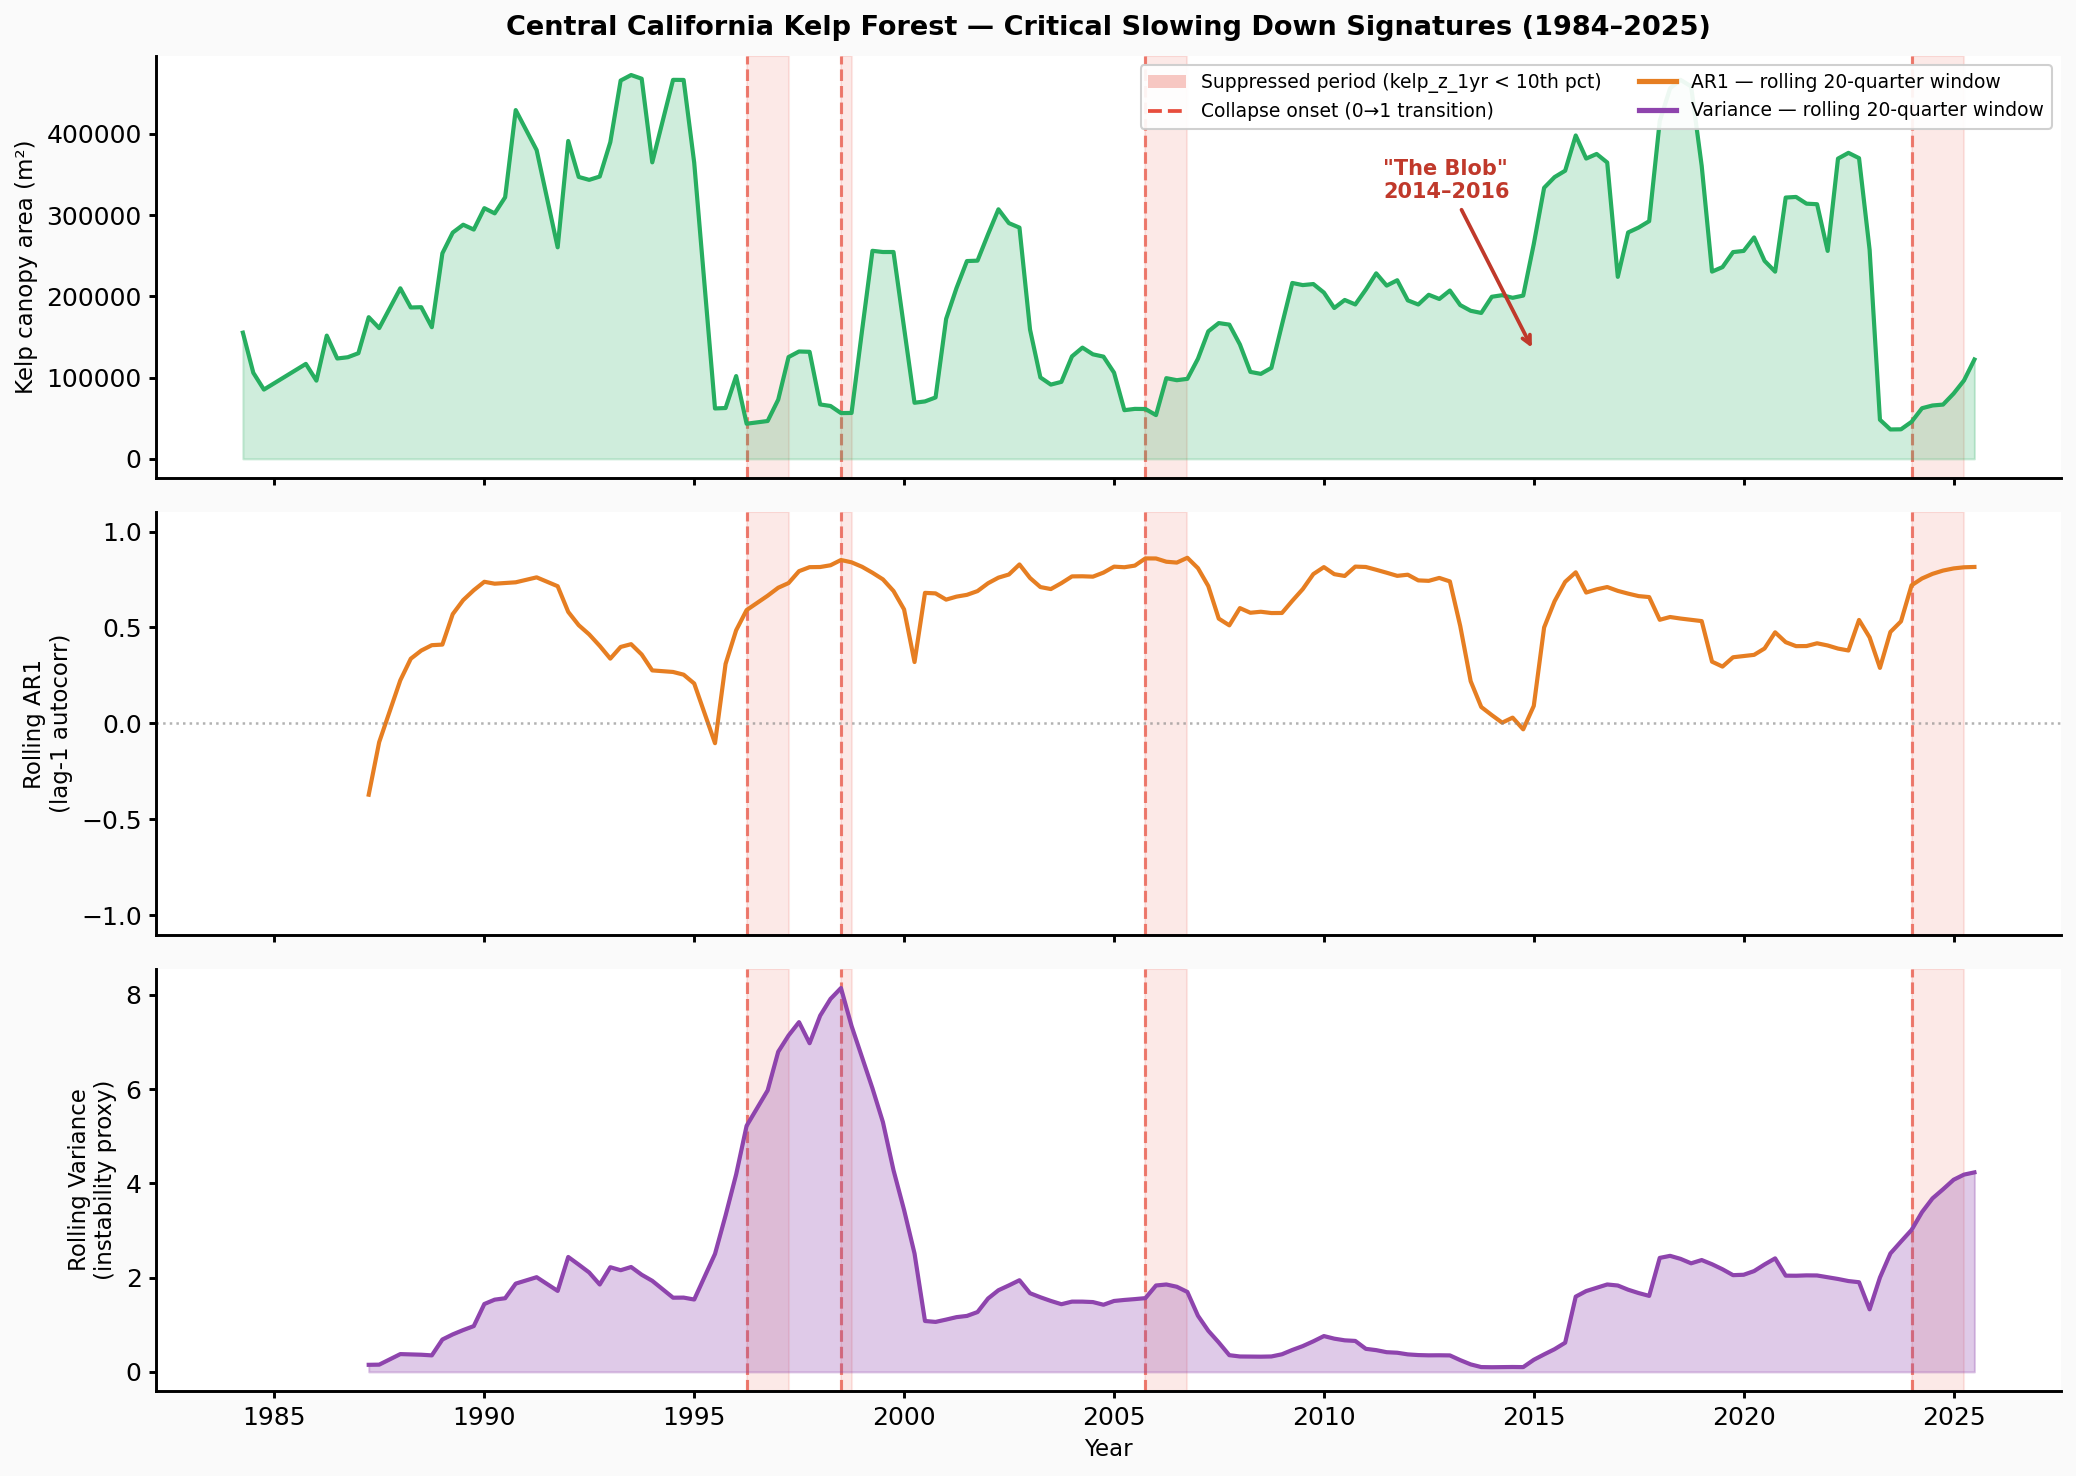

Saved: ../../5_FIGURES/isef_slides/slide7_A_ews_overview_midcal.png


In [4]:
# ============================================================
# CELL 4 — SLIDE 7, FIGURE A: 3-Panel EWS Overview (MidCal)
# The visual anchor. Shows kelp collapse + EWS rising before it.
# ============================================================
region = 'midcal'
df = region_dfs.get(region)
if df is None:
    print('MidCal not loaded. Check Cell 2.')
else:
    kelp_col = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
    onsets   = df.index[df['onset'] == 1]
    supp     = df['suppressed'].astype(int)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.patch.set_facecolor('#fafafa')

    for ax in axes:
        for _, grp in supp[supp==1].groupby((supp!=supp.shift()).cumsum()):
            ax.axvspan(grp.index[0], grp.index[-1], alpha=0.12, color='#e74c3c', zorder=0)
        for t in onsets:
            ax.axvline(t, color='#e74c3c', linestyle='--', lw=1.5, alpha=0.7, zorder=1)

    ax1 = axes[0]
    ax1.fill_between(df.index, df[kelp_col], alpha=0.22, color='#27ae60')
    ax1.plot(df.index, df[kelp_col], color='#27ae60', lw=2)
    ax1.set_ylabel('Kelp canopy area (m²)', fontsize=11)
    ax1.set_title('Central California Kelp Forest — Critical Slowing Down Signatures (1984–2025)',
                  fontsize=13, fontweight='bold', pad=10)


    ax2 = axes[1]
    ax2.plot(df.index, df['ar1'], color='#e67e22', lw=2)
    ax2.axhline(0, linestyle=':', color='gray', lw=1.2, alpha=0.6)
    ax2.set_ylabel('Rolling AR1\n(lag-1 autocorr)', fontsize=11)
    ax2.set_ylim(-1.1, 1.1)

    ax3 = axes[2]
    ax3.fill_between(df.index, df['variance'], alpha=0.28, color='#8e44ad')
    ax3.plot(df.index, df['variance'], color='#8e44ad', lw=2)
    ax3.set_ylabel('Rolling Variance\n(instability proxy)', fontsize=11)
    ax3.set_xlabel('Year', fontsize=11)

    legend_elements = [
        mpatches.Patch(facecolor='#e74c3c', alpha=0.3, label='Suppressed period (kelp_z_1yr < 10th pct)'),
        Line2D([0],[0], color='#e74c3c', linestyle='--', lw=1.8, label='Collapse onset (0→1 transition)'),
        Line2D([0],[0], color='#e67e22', lw=2.5, label='AR1 — rolling 20-quarter window'),
        Line2D([0],[0], color='#8e44ad', lw=2.5, label='Variance — rolling 20-quarter window'),
    ]
    axes[0].legend(handles=legend_elements, ncol=2, fontsize=9, loc='upper right')
    fig.tight_layout()
    out = FIG_DIR / 'slide7_A_ews_overview_midcal.png'
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
    plt.show()
    print(f'Saved: {out}')

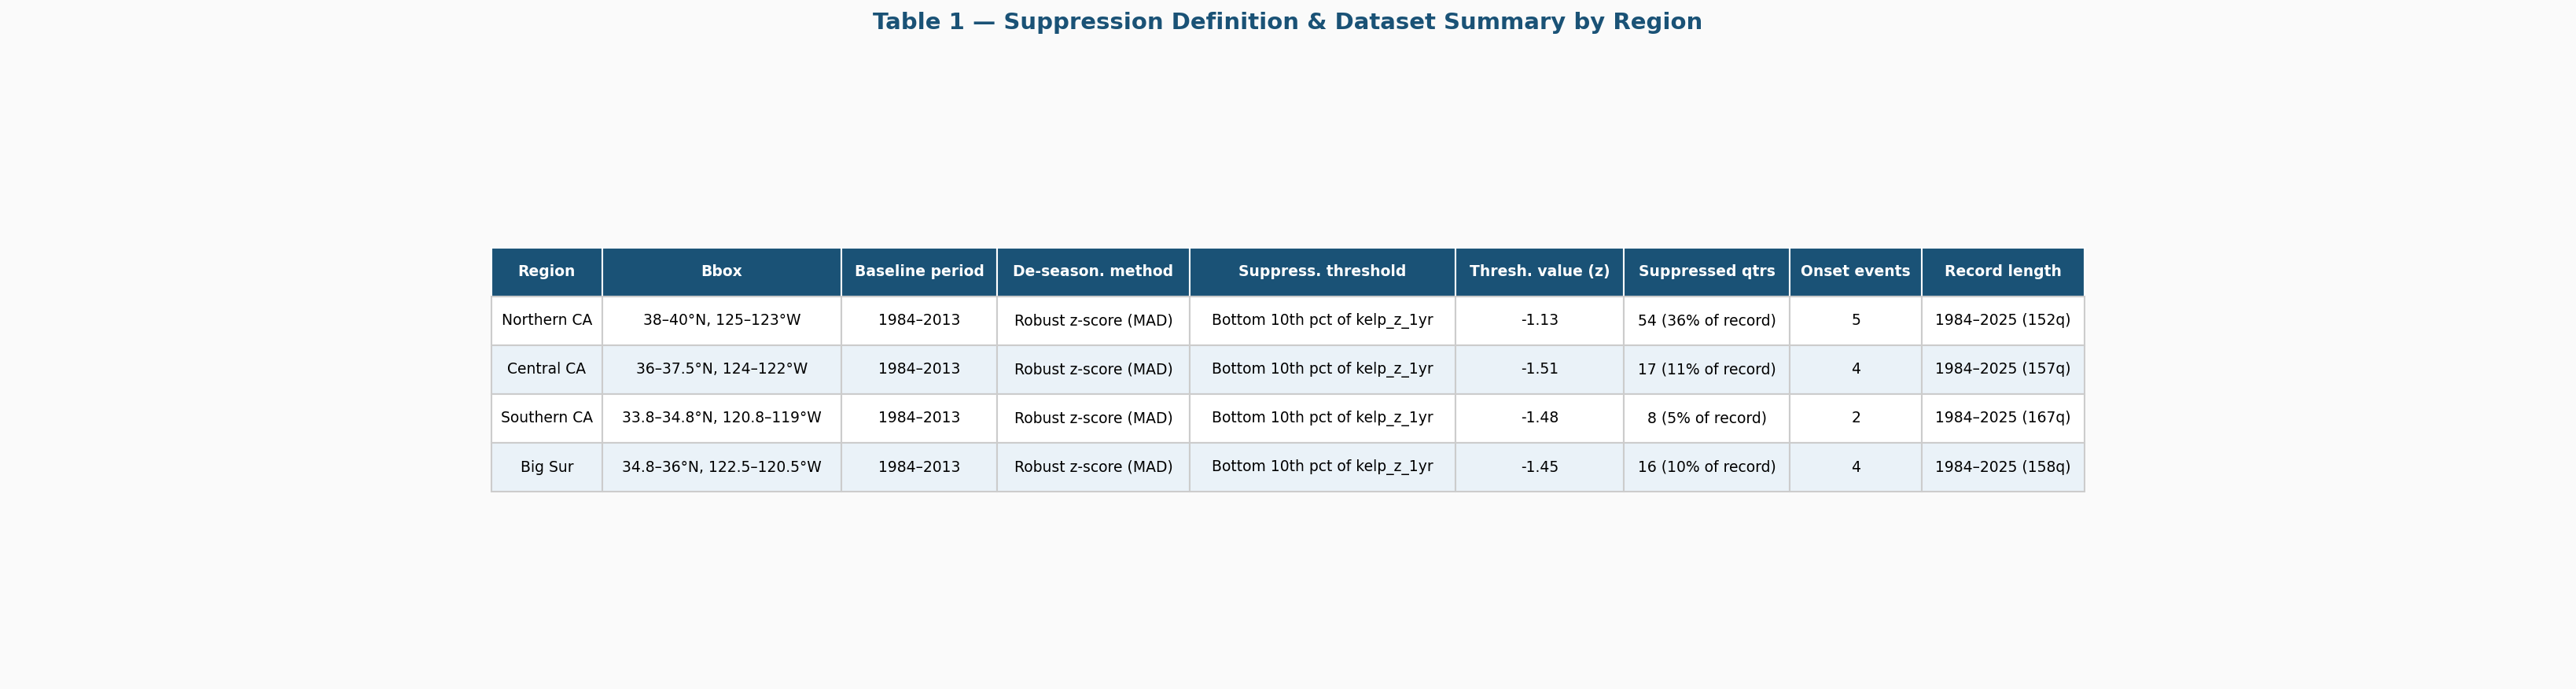

Saved: ../../5_FIGURES/isef_slides/slide7_T1_suppression_definition.png


In [15]:
# ============================================================
# CELL 5 — SLIDE 7: SUPPRESSION DEFINITION TABLE
# Shows exactly how suppression was defined for each region —
# the thresholds, baseline period, onset counts.
# ============================================================
supp_rows = []
for region, df in region_dfs.items():
    kelp_col = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
    baseline = df.loc['1984':'2013', 'kelp_q_z'].dropna()

    # Quarterly baseline stats
    q_stats = []
    for q in [1,2,3,4]:
        vals = df.loc['1984':'2013'][df.loc['1984':'2013'].index.quarter==q][kelp_col]
        q_stats.append(f'Q{q}: med={vals.median():.0f}')

    sup_thresh_val = baseline.quantile(0.10) if len(baseline) > 0 else np.nan
    n_sup  = int(df['suppressed'].sum())
    n_onset = int(df['onset'].sum())
    pct_sup = 100 * n_sup / len(df)

    bbox_str = {
        'norcal':  '38–40°N, 125–123°W',
        'midcal':  '36–37.5°N, 124–122°W',
        'socal':   '33.8–34.8°N, 120.8–119°W',
        'bigsur':  '34.8–36°N, 122.5–120.5°W',
    }.get(region, '—')

    supp_rows.append({
        'Region':              REGION_NAMES[region],
        'Bbox':                bbox_str,
        'Baseline period':     '1984–2013',
        'De-season. method':   'Robust z-score (MAD)',
        'Suppress. threshold': 'Bottom 10th pct of kelp_z_1yr',
        'Thresh. value (z)':   f'{sup_thresh_val:.2f}' if not np.isnan(sup_thresh_val) else 'N/A',
        'Suppressed qtrs':     f'{n_sup} ({pct_sup:.0f}% of record)',
        'Onset events':        str(n_onset),
        'Record length':       f'{df.index.min().year}–{df.index.max().year} ({len(df)}q)',
    })

supp_df = pd.DataFrame(supp_rows)
supp_df.to_csv(FIG_DIR / 'slide7_suppression_definition_table.csv', index=False)

fig, ax = plt.subplots(figsize=(22, 6))
fig.patch.set_facecolor('#fafafa')
ax.axis('off')

# Build the table
table = ax.table(
    cellText=supp_df.values,
    colLabels=supp_df.columns,
    cellLoc='center',
    loc='center',
)

# Style it
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 2.2)  # 2.2 = taller rows for breathing room

# Header styling
for j in range(len(supp_df.columns)):
    cell = table[0, j]
    cell.set_facecolor('#1a5276')
    cell.set_text_props(color='white', fontweight='bold', fontsize=9)
    cell.set_edgecolor('white')

# Body styling — alternating row colors
for i in range(1, len(supp_df) + 1):
    for j in range(len(supp_df.columns)):
        cell = table[i, j]
        cell.set_edgecolor('#cccccc')
        cell.set_text_props(fontsize=9)
        if i % 2 == 0:
            cell.set_facecolor('#eaf2f8')
        else:
            cell.set_facecolor('white')

# Auto-fit column widths
table.auto_set_column_width(list(range(len(supp_df.columns))))

# Title
ax.set_title(
    'Table 1 — Suppression Definition & Dataset Summary by Region',
    fontsize=14, fontweight='bold', pad=20, color='#1a5276',
)

fig.tight_layout()
out = FIG_DIR / 'slide7_T1_suppression_definition.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

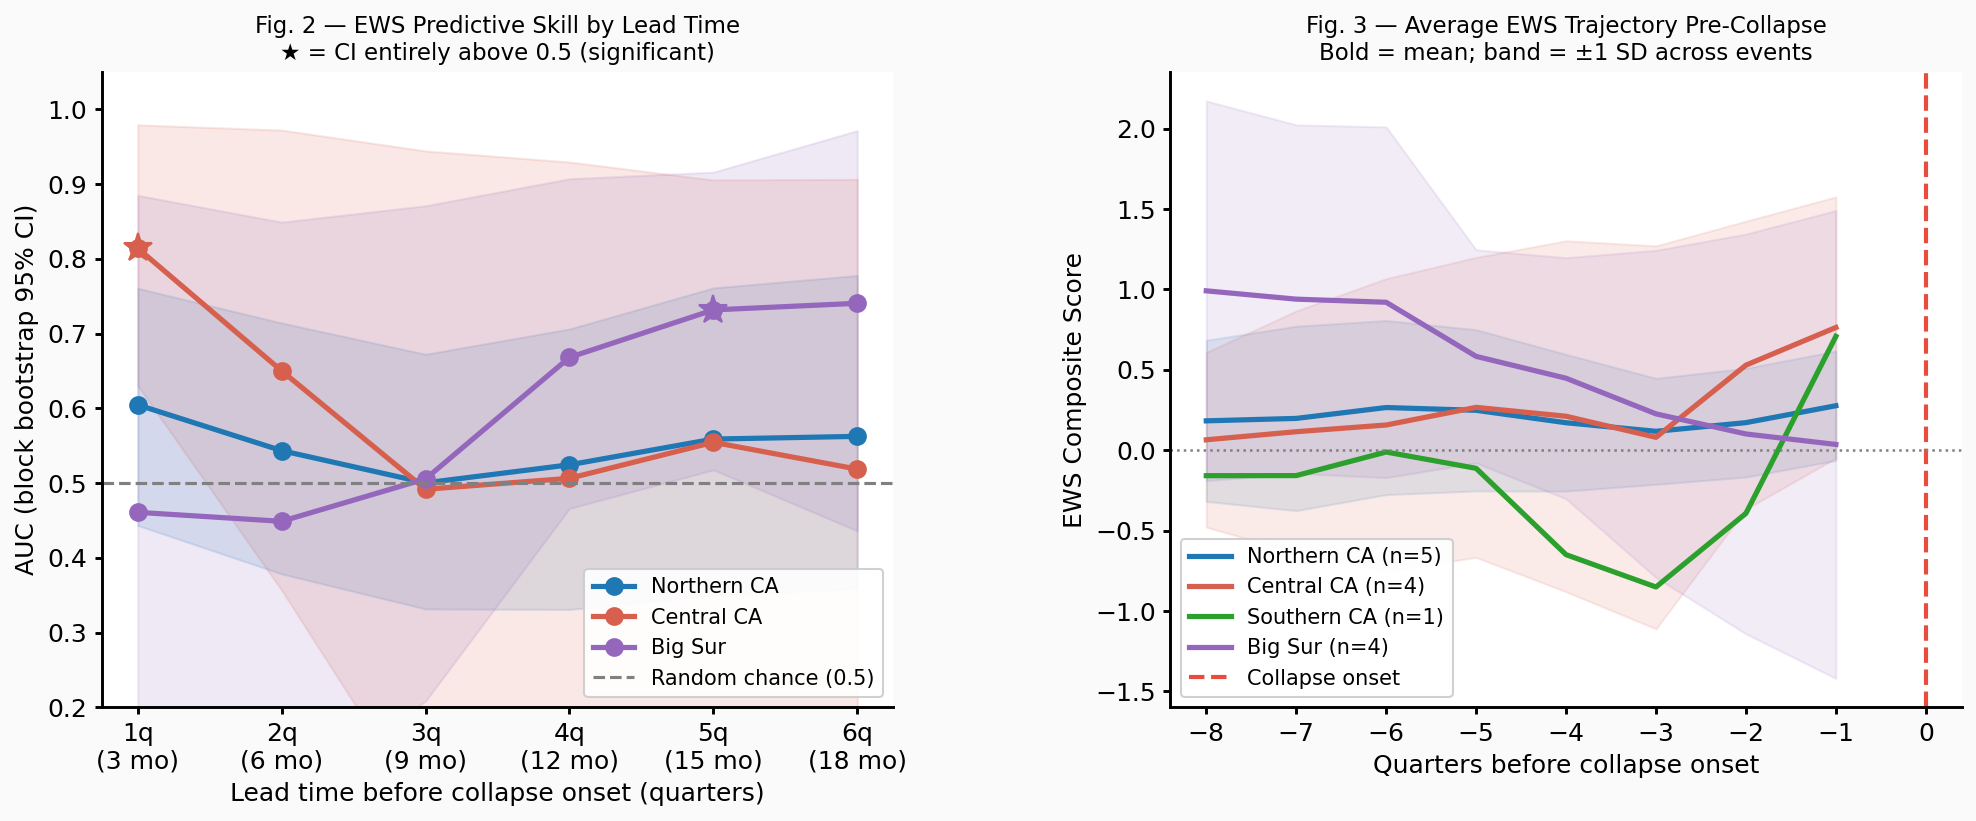

Saved: ../../5_FIGURES/isef_slides/slide7_BC_auc_and_trajectory.png


In [6]:
# ============================================================
# CELL 6 — SLIDE 7, FIGURE B: EWS AUC by Lead Time
# + FIGURE C: Pre-onset trajectory
# + FIGURE D: AR1 vs Variance comparison
# ============================================================

# --- Compute AUC by lead time ---
all_results = []
for region, df in region_dfs.items():
    for lead in range(1, 7):
        score = df['ews_composite'].shift(lead)
        y     = df['onset'].astype(int)
        tmp   = pd.DataFrame({'score':score,'y':y}).dropna()
        if tmp['y'].sum() < 2: continue
        out = block_bootstrap_auc(tmp['score'], tmp['y'], block_len=4, B=2000)
        all_results.append({'region':region,'lead':lead,
                            'auc':out['auc'],'ci_lo':out['ci_lo'],'ci_hi':out['ci_hi']})
res_df = pd.DataFrame(all_results)

fig = plt.figure(figsize=(16, 5.5))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)
fig.patch.set_facecolor('#fafafa')

# --- Figure B: AUC by lead time ---
ax_b = fig.add_subplot(gs[0])
for region in region_dfs:
    sub = res_df[res_df['region']==region]
    if sub.empty: continue
    c = REGION_COLORS[region]
    ax_b.plot(sub['lead'], sub['auc'], marker='o', markersize=8, label=REGION_NAMES[region],
              color=c, lw=2.5)
    ax_b.fill_between(sub['lead'], sub['ci_lo'], sub['ci_hi'], alpha=0.14, color=c)
    for _, row in sub.iterrows():
        if row['ci_lo'] > 0.5:
            ax_b.plot(row['lead'], row['auc'], marker='*', markersize=14,
                      color=c, zorder=5)
ax_b.axhline(0.5, linestyle='--', color='gray', lw=1.5, label='Random chance (0.5)')
ax_b.set_xlabel('Lead time before collapse onset (quarters)')
ax_b.set_ylabel('AUC (block bootstrap 95% CI)')
ax_b.set_title('Fig. 2 — EWS Predictive Skill by Lead Time\n★ = CI entirely above 0.5 (significant)',
               fontsize=11)
ax_b.set_ylim(0.2, 1.05)
ax_b.set_xticks([1,2,3,4,5,6])
ax_b.set_xticklabels(['1q\n(3 mo)','2q\n(6 mo)','3q\n(9 mo)','4q\n(12 mo)','5q\n(15 mo)','6q\n(18 mo)'])
ax_b.legend(fontsize=10)

# --- Figure C: Pre-onset trajectory ---
ax_c = fig.add_subplot(gs[1])
WINDOW_BEFORE = 8
for region, df in region_dfs.items():
    onset_times = df.index[df['onset']==1]
    traces = []
    for t in onset_times:
        loc = df.index.get_loc(t)
        if loc < WINDOW_BEFORE: continue
        win = df.iloc[loc-WINDOW_BEFORE:loc]['ews_composite'].values
        if len(win)==WINDOW_BEFORE: traces.append(win)
    if not traces: continue
    arr  = np.array(traces)
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0)
    x    = np.arange(-WINDOW_BEFORE, 0)
    c    = REGION_COLORS[region]
    ax_c.fill_between(x, mean-std, mean+std, alpha=0.12, color=c)
    ax_c.plot(x, mean, color=c, lw=2.5, label=f'{REGION_NAMES[region]} (n={len(traces)})')
ax_c.axvline(0, linestyle='--', color='#e74c3c', lw=2, label='Collapse onset')
ax_c.axhline(0, linestyle=':', color='gray', lw=1.2)
ax_c.set_xlabel('Quarters before collapse onset')
ax_c.set_ylabel('EWS Composite Score')
ax_c.set_title('Fig. 3 — Average EWS Trajectory Pre-Collapse\nBold = mean; band = ±1 SD across events', fontsize=11)
ax_c.legend(fontsize=10)
fig.tight_layout()
out = FIG_DIR / 'slide7_BC_auc_and_trajectory.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

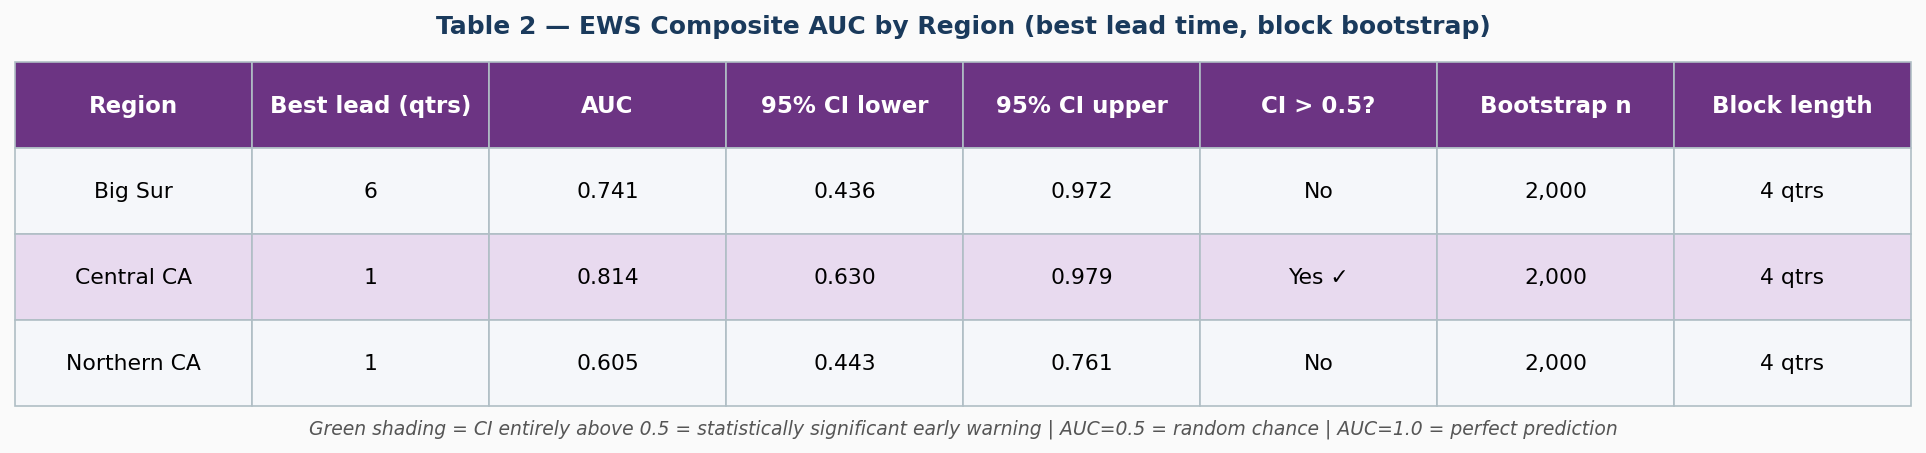

Saved: ../../5_FIGURES/isef_slides/slide7_T2_ews_auc_table.png


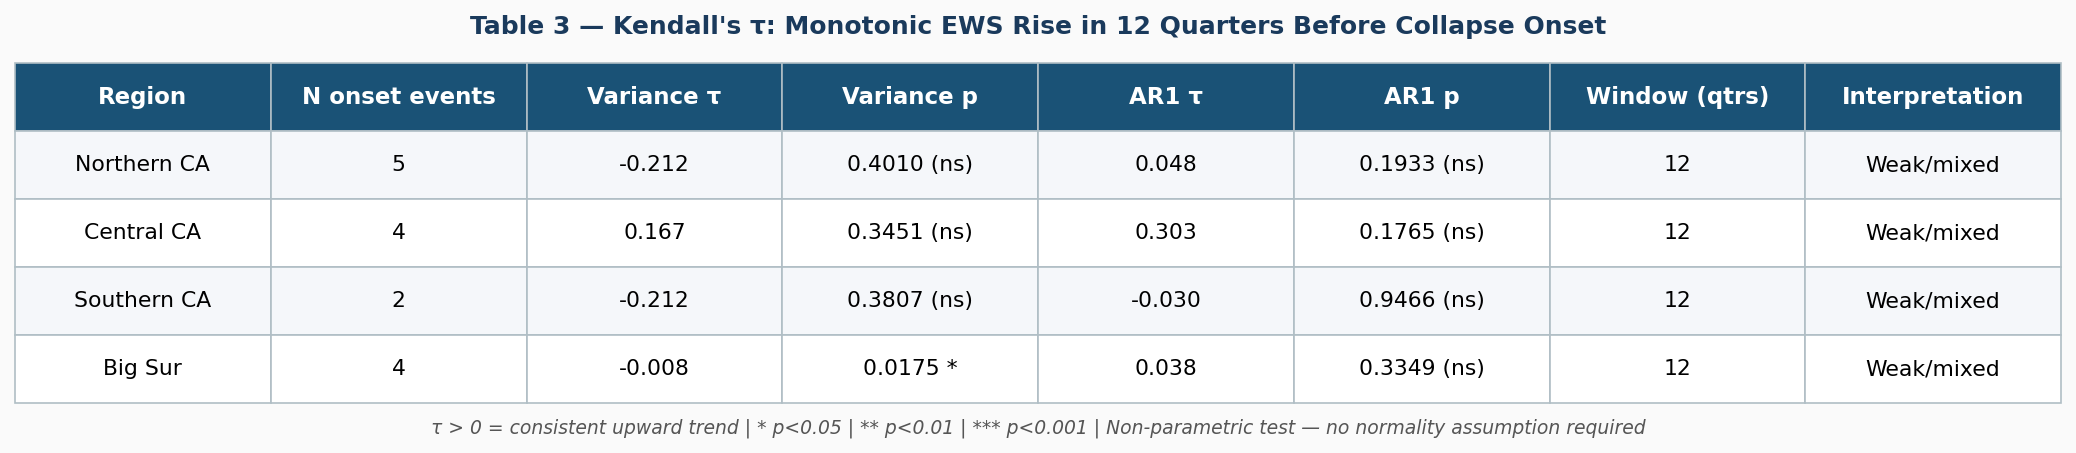

Saved: ../../5_FIGURES/isef_slides/slide7_T3_kendall_tau.png

=== TABLE 2 ===
     Region  Best lead (qtrs)   AUC 95% CI lower 95% CI upper CI > 0.5? Bootstrap n Block length
    Big Sur                 6 0.741        0.436        0.972        No       2,000       4 qtrs
 Central CA                 1 0.814        0.630        0.979     Yes ✓       2,000       4 qtrs
Northern CA                 1 0.605        0.443        0.761        No       2,000       4 qtrs

=== TABLE 3 ===
     Region  N onset events Variance τ  Variance p  AR1 τ       AR1 p  Window (qtrs) Interpretation
Northern CA               5     -0.212 0.4010 (ns)  0.048 0.1933 (ns)             12     Weak/mixed
 Central CA               4      0.167 0.3451 (ns)  0.303 0.1765 (ns)             12     Weak/mixed
Southern CA               2     -0.212 0.3807 (ns) -0.030 0.9466 (ns)             12     Weak/mixed
    Big Sur               4     -0.008    0.0175 *  0.038 0.3349 (ns)             12     Weak/mixed


In [7]:
# ============================================================
# CELL 7 — SLIDE 7: STATISTICAL SIGNIFICANCE TABLES
# Table 2: EWS AUC with block bootstrap CI — all regions/leads
# Table 3: Kendall's tau — monotonic EWS rise before onset
# ============================================================

# ---- TABLE 2: EWS AUC Summary ----
best_ews = res_df.sort_values('auc', ascending=False).groupby('region').first().reset_index()
t2_rows = []
for _, row in best_ews.iterrows():
    sig = 'Yes ✓' if row['ci_lo'] > 0.5 else 'No'
    t2_rows.append({
        'Region':         REGION_NAMES[row['region']],
        'Best lead (qtrs)': int(row['lead']),
        'AUC':            f"{row['auc']:.3f}",
        '95% CI lower':   f"{row['ci_lo']:.3f}",
        '95% CI upper':   f"{row['ci_hi']:.3f}",
        'CI > 0.5?':      sig,
        'Bootstrap n':    '2,000',
        'Block length':   '4 qtrs',
    })
t2_df = pd.DataFrame(t2_rows)

# Rows where CI > 0.5 are highlighted
highlight_t2 = [i for i, row in enumerate(t2_rows) if row['CI > 0.5?'].startswith('Yes')]

fig, ax = plt.subplots(figsize=(13, 3.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t2_df,
    title='Table 2 — EWS Composite AUC by Region (best lead time, block bootstrap)',
    header_color='#6c3483',
    highlight_rows=highlight_t2,
    highlight_color='#e8daef')
ax.text(0.5, -0.08,
    'Green shading = CI entirely above 0.5 = statistically significant early warning | '
    'AUC=0.5 = random chance | AUC=1.0 = perfect prediction',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide7_T2_ews_auc_table.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- TABLE 3: Kendall's Tau ----
WINDOW = 12
t3_rows = []
for region, df in region_dfs.items():
    onset_times = df.index[df['onset']==1]
    tau_vars, p_vars, tau_ar1s, p_ar1s = [], [], [], []
    for t in onset_times:
        loc = df.index.get_loc(t)
        if loc < WINDOW: continue
        w_var = df['variance'].iloc[loc-WINDOW:loc].dropna()
        w_ar1 = df['ar1'].iloc[loc-WINDOW:loc].dropna()
        if len(w_var) >= 6:
            tv, pv = kendalltau(np.arange(len(w_var)), w_var.values)
            tau_vars.append(tv); p_vars.append(pv)
        if len(w_ar1) >= 6:
            ta, pa = kendalltau(np.arange(len(w_ar1)), w_ar1.values)
            tau_ar1s.append(ta); p_ar1s.append(pa)

    mv = np.mean(tau_vars) if tau_vars else np.nan
    pv = np.mean(p_vars)   if p_vars   else np.nan
    ma = np.mean(tau_ar1s) if tau_ar1s else np.nan
    pa = np.mean(p_ar1s)   if p_ar1s   else np.nan
    n_events = int(df['onset'].sum())

    t3_rows.append({
        'Region':          REGION_NAMES[region],
        'N onset events':  n_events,
        'Variance τ':      f'{mv:.3f}' if not np.isnan(mv) else 'N/A',
        'Variance p':      f'{pv:.4f}{sig_stars(pv)}' if not np.isnan(pv) else 'N/A',
        'AR1 τ':           f'{ma:.3f}' if not np.isnan(ma) else 'N/A',
        'AR1 p':           f'{pa:.4f}{sig_stars(pa)}' if not np.isnan(pa) else 'N/A',
        'Window (qtrs)':   WINDOW,
        'Interpretation':  ('Rising ✓' if (not np.isnan(mv) and mv > 0.2) else
                           'Weak/mixed')
    })

t3_df = pd.DataFrame(t3_rows)
highlight_t3 = [i for i, r in enumerate(t3_rows) if r['Interpretation'].startswith('Rising')]

fig, ax = plt.subplots(figsize=(14, 3.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t3_df,
    title="Table 3 — Kendall's τ: Monotonic EWS Rise in 12 Quarters Before Collapse Onset",
    header_color='#1a5276',
    highlight_rows=highlight_t3,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.09,
    'τ > 0 = consistent upward trend | * p<0.05 | ** p<0.01 | *** p<0.001 | '
    'Non-parametric test — no normality assumption required',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide7_T3_kendall_tau.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')
print('\n=== TABLE 2 ===')
print(t2_df.to_string(index=False))
print('\n=== TABLE 3 ===')
print(t3_df.to_string(index=False))

---
---
# ══════════════════════════════════════════════
# SLIDE 8 — "MACHINE LEARNING PERFORMANCE"
# ══════════════════════════════════════════════
**Core claim:** A logistic regression combining EWS, SST heat stress, and upwelling anomaly outperforms SST alone. EWS is the top feature by permutation importance, meaning *internal ecosystem state* carries more predictive power than external stressors.

**Validation method:** Leave-One-Region-Out (LORO) cross-validation. The model is trained on 3 regions and tested on the 4th — repeated for all folds. The model never sees any data from the test region during training. Big Sur serves as an additional fully out-of-sample holdout.

In [8]:
# ============================================================
# CELL 8 — SLIDE 8: BUILD LORO OUT-OF-FOLD PREDICTIONS
# All model variants + permutation importance
# ============================================================
oof_full = {'y':[],'prob':[]}
oof_sst  = {'y':[],'prob':[]}
oof_ews  = {'y':[],'prob':[]}
perm_importance = {f:[] for f in FEATURES}
loro_rows = []

for held_out in region_dfs:
    train_regions = [r for r in region_dfs if r != held_out]
    train_df = pd.concat([region_dfs[r][FEATURES+[TARGET]].dropna() for r in train_regions])
    test_df  = region_dfs[held_out][FEATURES+[TARGET]].dropna()

    if train_df[TARGET].sum() < 2 or len(test_df[TARGET].unique()) < 2: continue

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(train_df[FEATURES])
    X_te_s = scaler.transform(test_df[FEATURES])
    y_tr   = train_df[TARGET].astype(int).values
    y_te   = test_df[TARGET].astype(int).values

    # Full model
    lr = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr.fit(X_tr_s, y_tr)
    p_full = lr.predict_proba(X_te_s)[:, 1]
    oof_full['y'].extend(y_te); oof_full['prob'].extend(p_full)

    # SST-only
    fi_sst = FEATURES.index('heat_lag4')
    lr_sst = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr_sst.fit(X_tr_s[:,[fi_sst]], y_tr)
    p_sst = lr_sst.predict_proba(X_te_s[:,[fi_sst]])[:, 1]
    oof_sst['y'].extend(y_te); oof_sst['prob'].extend(p_sst)

    # EWS-only
    fi_ews = FEATURES.index('ews_composite')
    lr_ews = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr_ews.fit(X_tr_s[:,[fi_ews]], y_tr)
    p_ews = lr_ews.predict_proba(X_te_s[:,[fi_ews]])[:, 1]
    oof_ews['y'].extend(y_te); oof_ews['prob'].extend(p_ews)

    # LORO row for table
    auc_full_fold = roc_auc_score(y_te, p_full)
    auc_sst_fold  = roc_auc_score(y_te, p_sst)
    loro_rows.append({'held_out':held_out,
                      'n_test':len(y_te), 'n_onset':int(y_te.sum()),
                      'auc_full':auc_full_fold, 'auc_sst':auc_sst_fold,
                      'delta_auc':auc_full_fold - auc_sst_fold})

    # Permutation importance on test set
    rng = np.random.default_rng(42)
    for fi, fname in enumerate(FEATURES):
        drops = []
        for _ in range(100):
            X_shuf = X_te_s.copy()
            X_shuf[:, fi] = rng.permutation(X_shuf[:, fi])
            try: drops.append(auc_full_fold - roc_auc_score(y_te, lr.predict_proba(X_shuf)[:,1]))
            except: pass
        perm_importance[fname].extend(drops)

y_full = np.array(oof_full['y']); p_full = np.array(oof_full['prob'])
y_sst  = np.array(oof_sst['y']);  p_sst  = np.array(oof_sst['prob'])
y_ews  = np.array(oof_ews['y']);  p_ews  = np.array(oof_ews['prob'])
loro_df = pd.DataFrame(loro_rows)
imp_means = {f: np.mean(v) for f,v in perm_importance.items() if v}
imp_stds  = {f: np.std(v)  for f,v in perm_importance.items() if v}

print('✓ LORO predictions built.')
print(f'  Total test-set quarters: {len(y_full)}')
print(f'  Total onset events:      {int(y_full.sum())}')
for row in loro_rows:
    print(f"  {row['held_out']:8s}: test n={row['n_test']} onset={row['n_onset']} "
          f"AUC_full={row['auc_full']:.3f} AUC_sst={row['auc_sst']:.3f} "
          f"Δ={row['delta_auc']:+.3f}")

✓ LORO predictions built.
  Total test-set quarters: 594
  Total onset events:      14
  norcal  : test n=143 onset=5 AUC_full=0.796 AUC_sst=0.639 Δ=+0.157
  midcal  : test n=148 onset=4 AUC_full=0.887 AUC_sst=0.569 Δ=+0.318
  socal   : test n=154 onset=1 AUC_full=0.791 AUC_sst=0.529 Δ=+0.261
  bigsur  : test n=149 onset=4 AUC_full=0.731 AUC_sst=0.562 Δ=+0.169


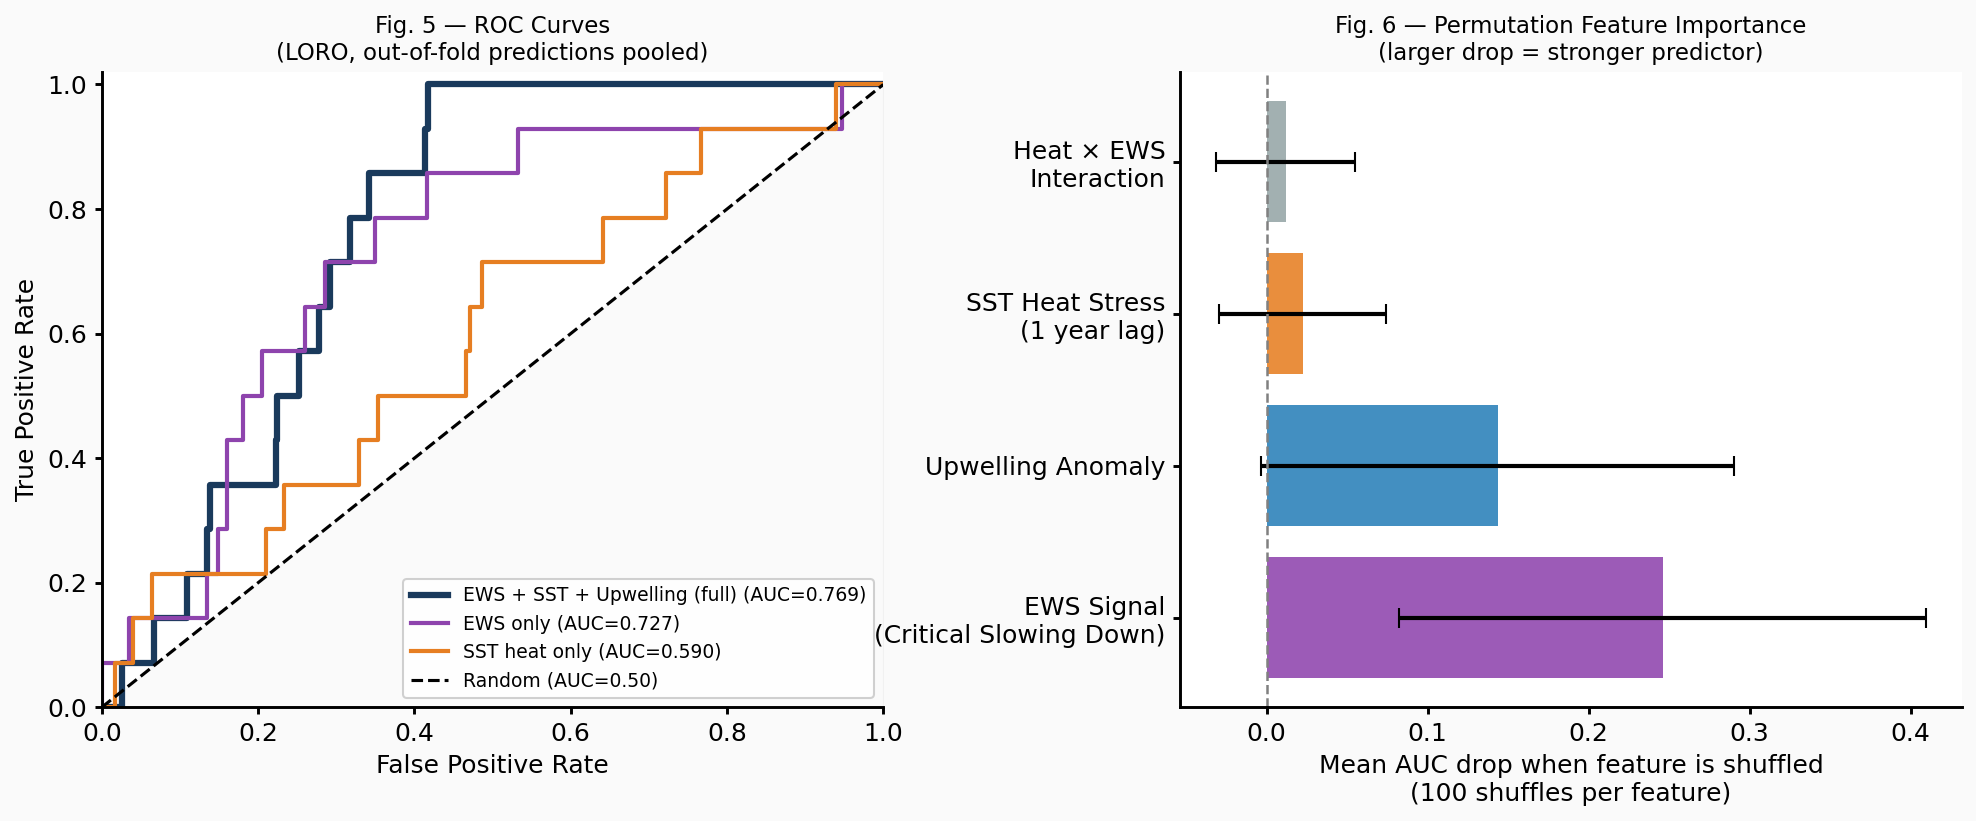

Saved: ../../5_FIGURES/isef_slides/slide8_A_roc_importance.png


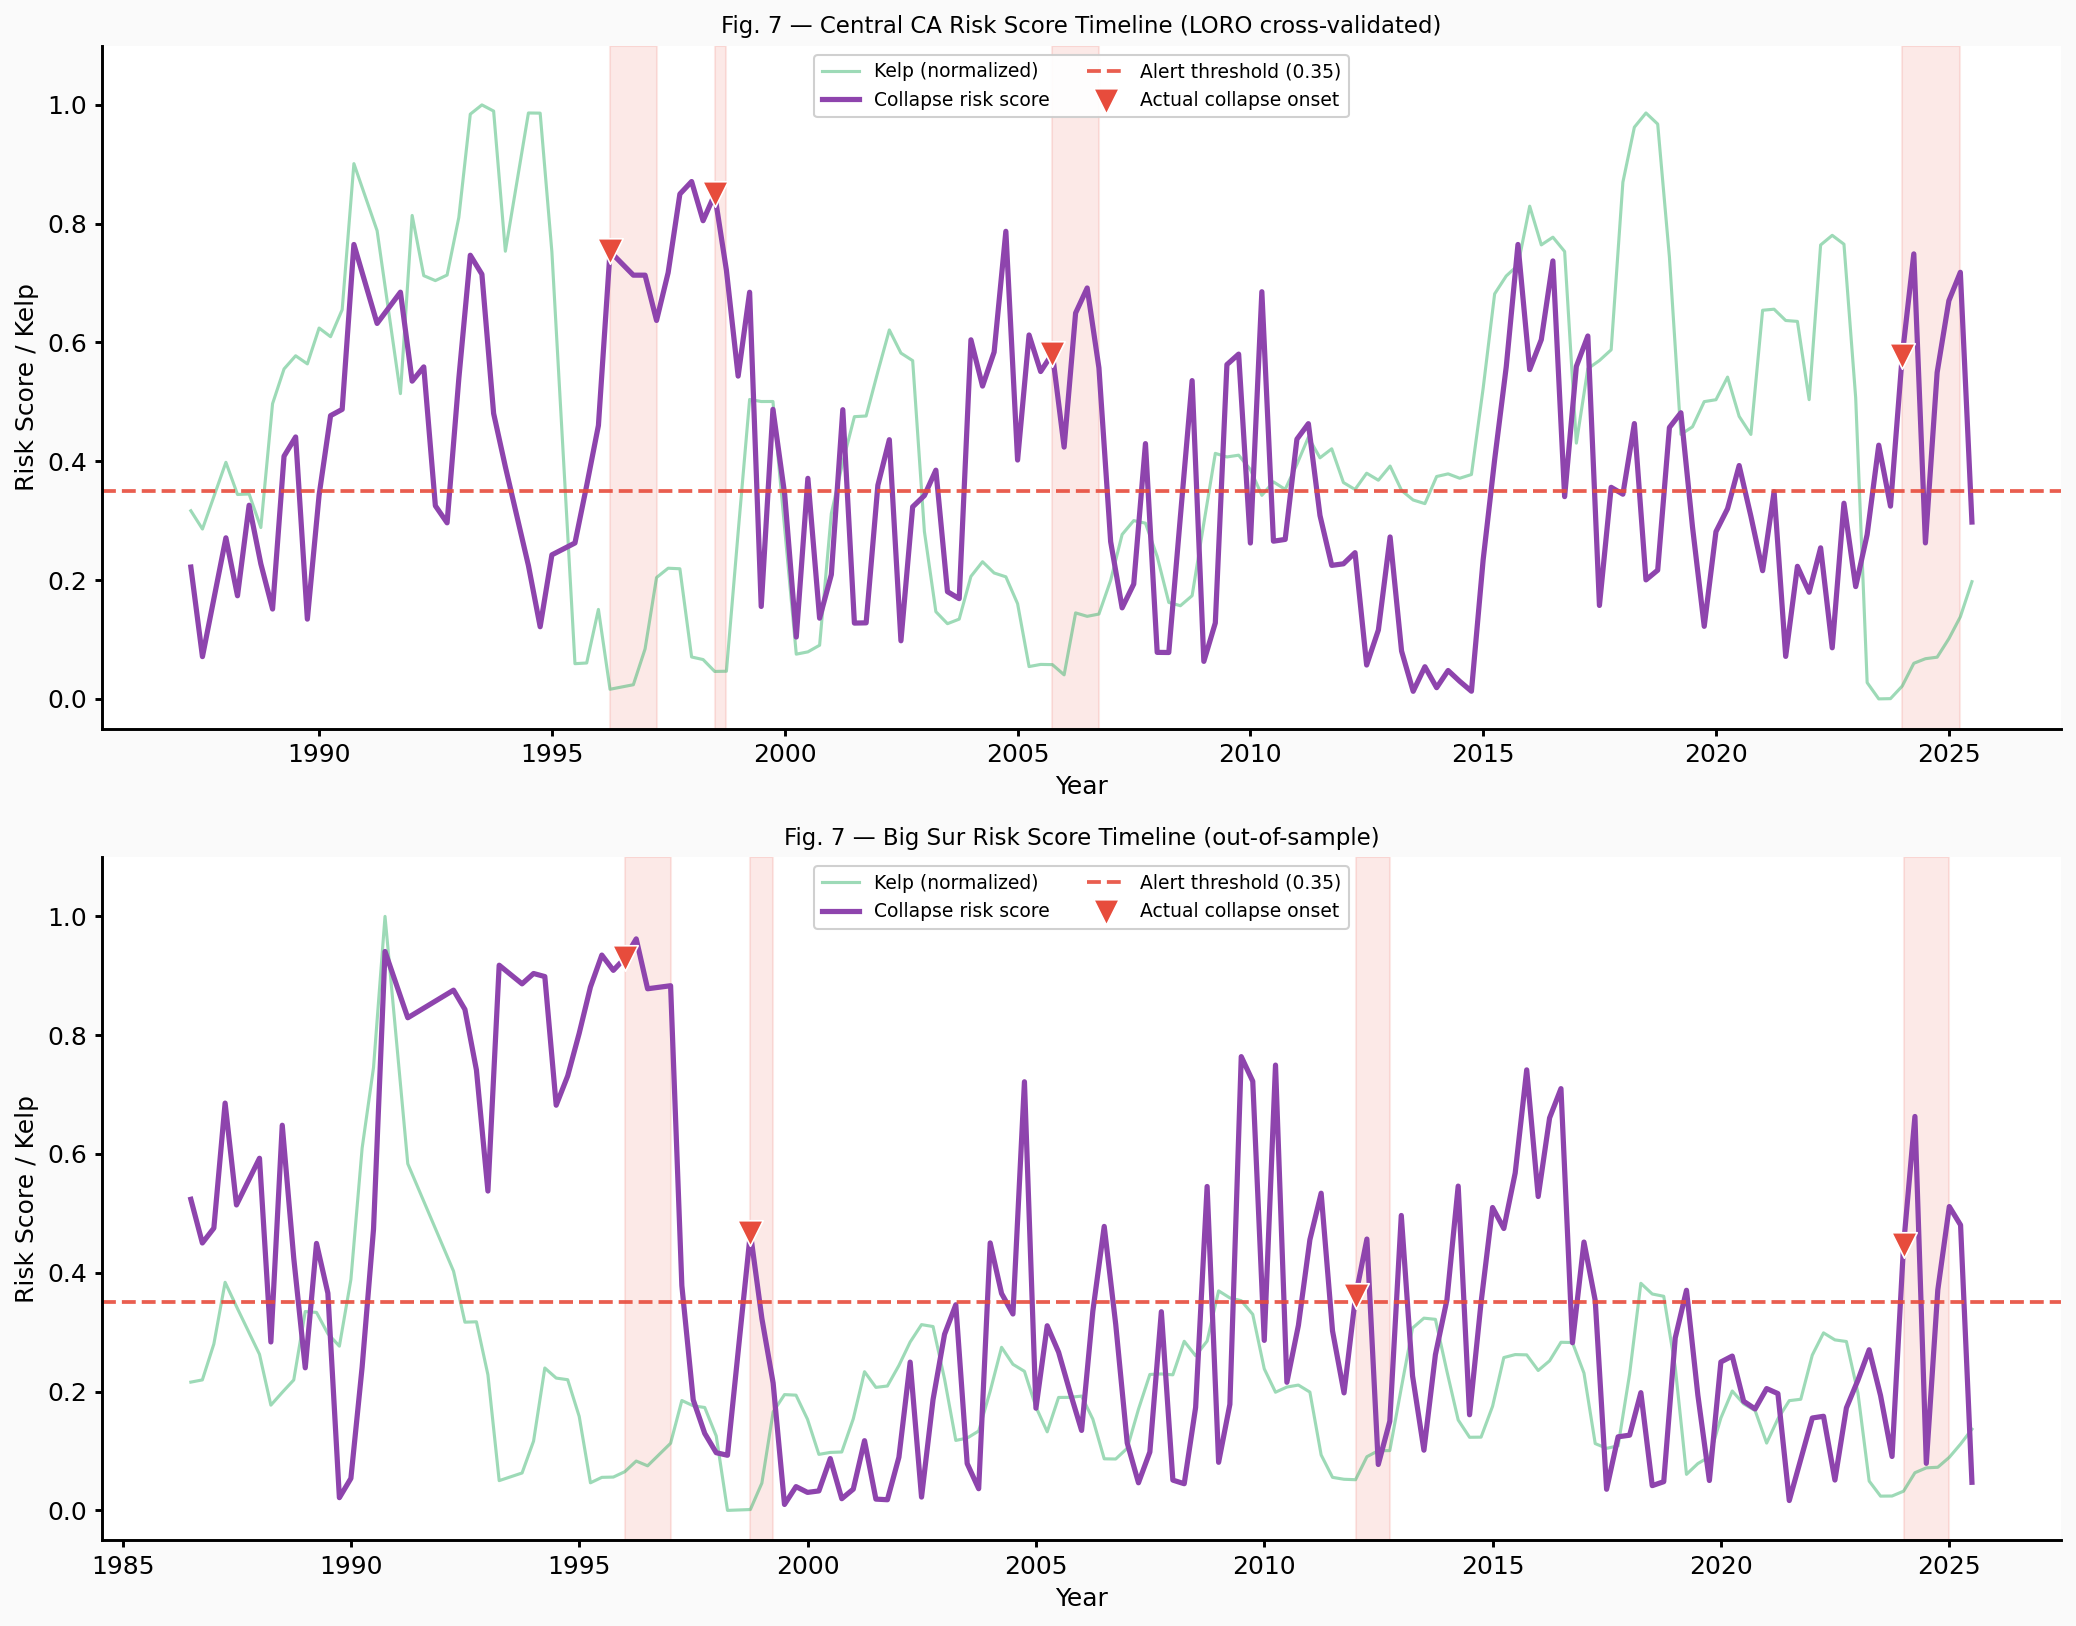

Saved: ../../5_FIGURES/isef_slides/slide8_B_risk_timeline.png


In [9]:
# ============================================================
# CELL 9 — SLIDE 8, FIGURES: ROC + Feature Importance + Timeline
# ============================================================

fig = plt.figure(figsize=(16, 5.5))
gs  = gridspec.GridSpec(1, 2, wspace=0.38)
fig.patch.set_facecolor('#fafafa')

# --- ROC curves ---
ax_roc = fig.add_subplot(gs[0])
for y_arr, p_arr, label, color, lw in [
    (y_full, p_full, 'EWS + SST + Upwelling (full)', '#1a3a5c', 3.0),
    (y_ews,  p_ews,  'EWS only',                     '#8e44ad', 2.0),
    (y_sst,  p_sst,  'SST heat only',                 '#e67e22', 2.0),
]:
    if len(np.unique(y_arr)) < 2: continue
    fpr, tpr, _ = roc_curve(y_arr, p_arr)
    roc_auc_val = sklearn_auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=lw,
                label=f'{label} (AUC={roc_auc_val:.3f})')
ax_roc.plot([0,1],[0,1],'k--',lw=1.5, label='Random (AUC=0.50)')
ax_roc.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Fig. 5 — ROC Curves\n(LORO, out-of-fold predictions pooled)', fontsize=11)
ax_roc.legend(fontsize=9, loc='lower right')
ax_roc.set_xlim(0,1); ax_roc.set_ylim(0,1.02)

# --- Feature importance ---
ax_imp = fig.add_subplot(gs[1])
feat_labels = {
    'ews_composite': 'EWS Signal\n(Critical Slowing Down)',
    'heat_lag4':     'SST Heat Stress\n(1 year lag)',
    'upwelling':     'Upwelling Anomaly',
    'heat_x_ews':    'Heat × EWS\nInteraction'
}
feat_colors = {
    'ews_composite':'#8e44ad','heat_lag4':'#e67e22',
    'upwelling':'#2980b9','heat_x_ews':'#95a5a6'
}
sorted_feats = sorted(imp_means, key=imp_means.get, reverse=True)
ax_imp.barh(
    [feat_labels.get(f,f) for f in sorted_feats],
    [imp_means[f] for f in sorted_feats],
    xerr=[imp_stds[f] for f in sorted_feats],
    color=[feat_colors.get(f,'gray') for f in sorted_feats],
    alpha=0.88, capsize=5, error_kw={'linewidth':2}
)
ax_imp.axvline(0, color='gray', lw=1.2, linestyle='--')
ax_imp.set_xlabel('Mean AUC drop when feature is shuffled\n(100 shuffles per feature)')
ax_imp.set_title('Fig. 6 — Permutation Feature Importance\n(larger drop = stronger predictor)', fontsize=11)
fig.tight_layout()
out = FIG_DIR / 'slide8_A_roc_importance.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# --- Risk score timeline ---
show_regions = [r for r in ['midcal','bigsur'] if r in region_dfs]
fig2, axes = plt.subplots(len(show_regions), 1, figsize=(14, 5.5*len(show_regions)))
if len(show_regions)==1: axes=[axes]
fig2.patch.set_facecolor('#fafafa')
for ax, region in zip(axes, show_regions):
    df = region_dfs[region]
    train_regions = [r for r in region_dfs if r!=region]
    train_df = pd.concat([region_dfs[r][FEATURES+[TARGET]].dropna() for r in train_regions])
    test_df  = df[FEATURES+[TARGET]].dropna()
    if train_df[TARGET].sum()<2 or len(test_df[TARGET].unique())<2:
        continue
    scaler = StandardScaler()
    lr = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr.fit(scaler.fit_transform(train_df[FEATURES]), train_df[TARGET].astype(int).values)
    risk  = pd.Series(lr.predict_proba(scaler.transform(test_df[FEATURES]))[:,1], index=test_df.index)
    kelp_col = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
    k = df[kelp_col].reindex(risk.index)
    k_norm = (k - k.min()) / (k.max()-k.min()+1e-9)
    supp   = df['suppressed'].reindex(risk.index).fillna(0).astype(int)
    onset  = df['onset'].reindex(risk.index).fillna(0).astype(int)
    for _, grp in supp[supp==1].groupby((supp!=supp.shift()).cumsum()):
        ax.axvspan(grp.index[0], grp.index[-1], alpha=0.12, color='#e74c3c', zorder=0)
    ax.plot(risk.index, k_norm, color='#27ae60', alpha=0.45, lw=1.5, label='Kelp (normalized)')
    ax.plot(risk.index, risk, color='#8e44ad', lw=2.5, label='Collapse risk score')
    ax.axhline(THRESHOLD, linestyle='--', color='#e74c3c', alpha=0.9, lw=1.8,
               label=f'Alert threshold ({THRESHOLD})')
    ax.scatter(risk.index[onset==1], risk[onset==1],
               marker='v', s=150, color='#e74c3c', zorder=6,
               label='Actual collapse onset', edgecolors='white', lw=0.8)
    tag = '(out-of-sample)' if region=='bigsur' else '(LORO cross-validated)'
    ax.set_title(f'Fig. 7 — {REGION_NAMES[region]} Risk Score Timeline {tag}', fontsize=11)
    ax.set_ylabel('Risk Score / Kelp')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9, ncol=2)
    ax.set_xlabel('Year')
fig2.tight_layout()
out2 = FIG_DIR / 'slide8_B_risk_timeline.png'
fig2.savefig(out2, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out2}')

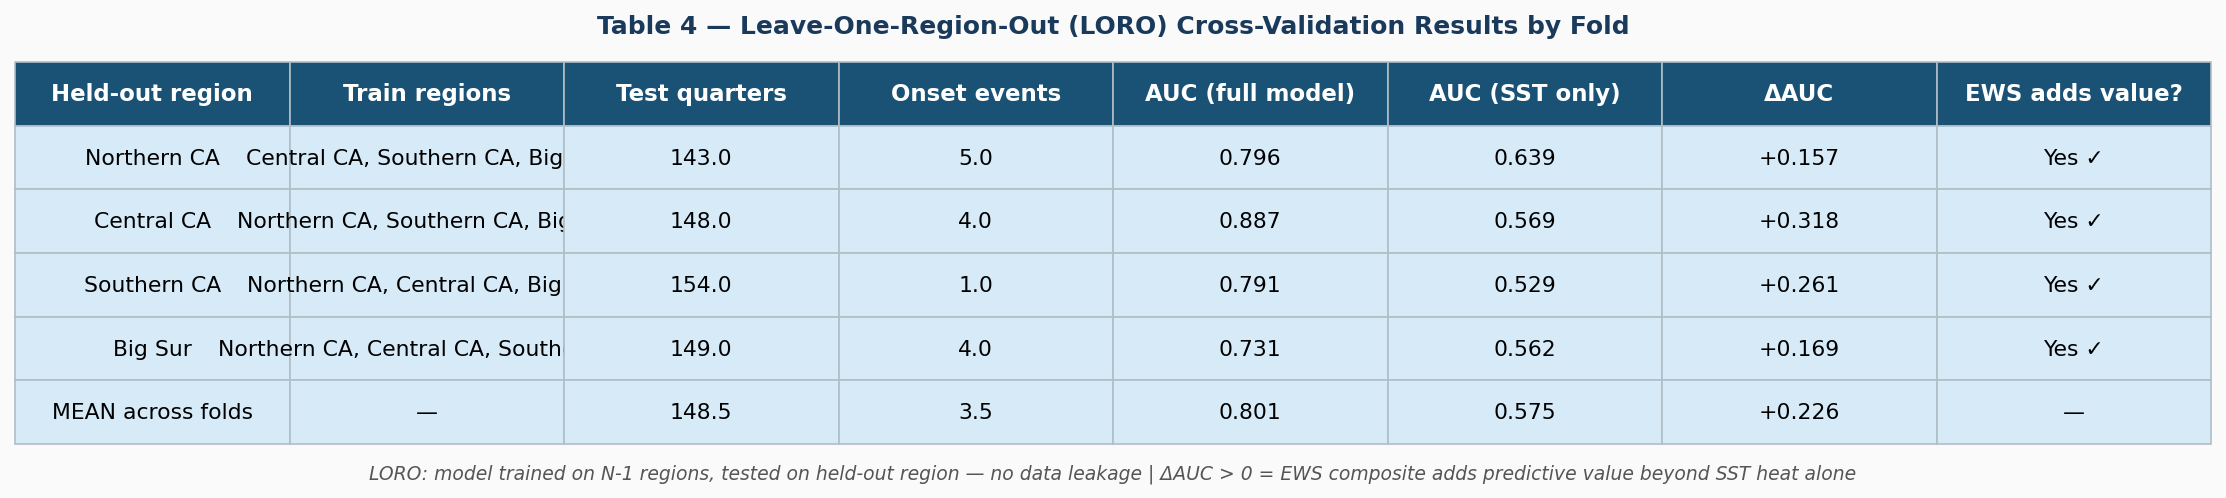

Saved: ../../5_FIGURES/isef_slides/slide8_T4_loro_folds.png


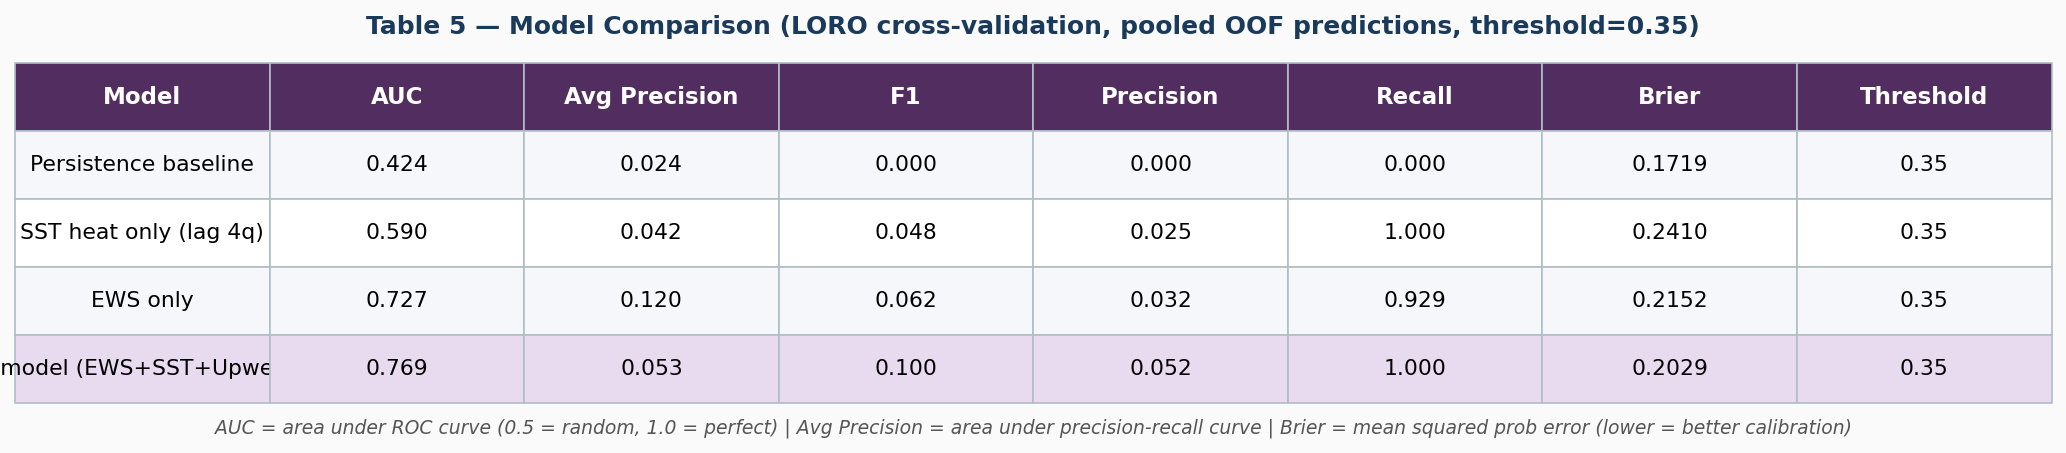

Saved: ../../5_FIGURES/isef_slides/slide8_T5_model_comparison.png


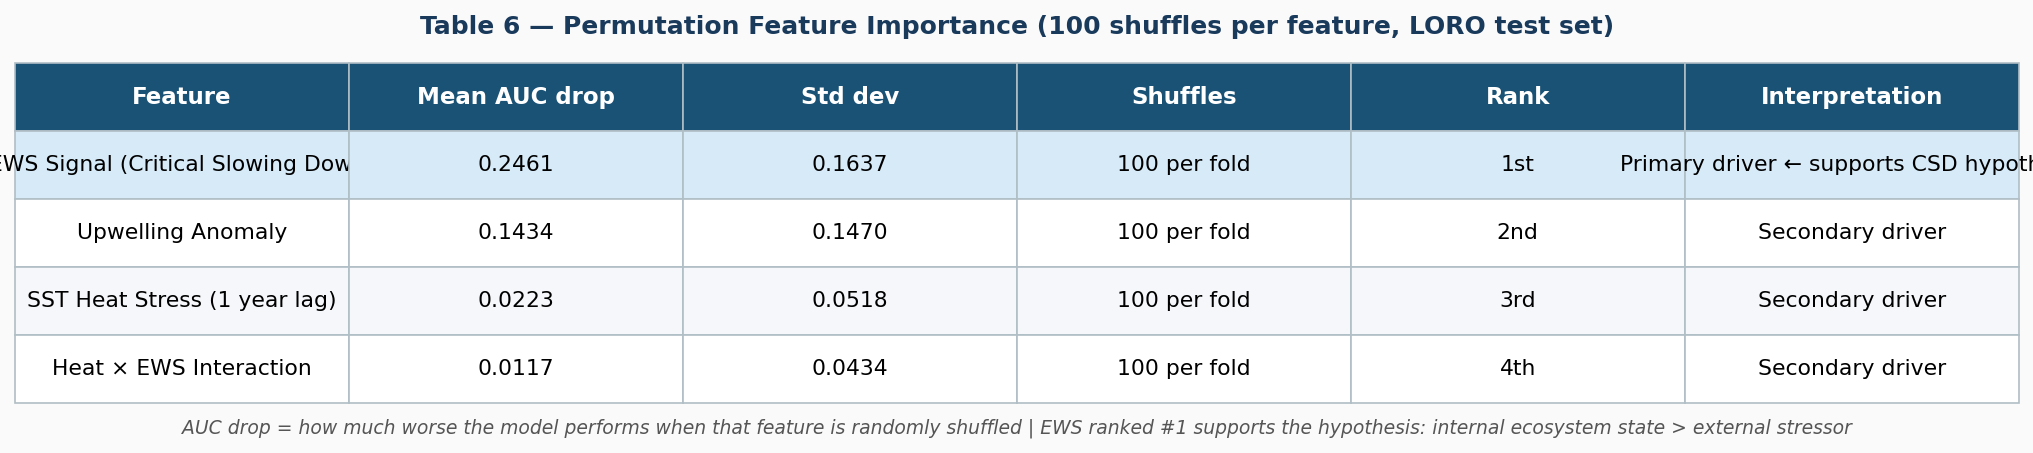

Saved: ../../5_FIGURES/isef_slides/slide8_T6_feature_importance.png


In [10]:
# ============================================================
# CELL 10 — SLIDE 8: STATISTICAL TABLES
# Table 4: LORO fold-by-fold results
# Table 5: Full model comparison (all metrics)
# Table 6: Permutation feature importance
# ============================================================

# ---- TABLE 4: LORO fold results ----
t4_rows = []
for row in loro_rows:
    t4_rows.append({
        'Held-out region': REGION_NAMES[row['held_out']],
        'Train regions':   ', '.join([REGION_NAMES[r] for r in region_dfs if r!=row['held_out']]),
        'Test quarters':   row['n_test'],
        'Onset events':    row['n_onset'],
        'AUC (full model)':f"{row['auc_full']:.3f}",
        'AUC (SST only)':  f"{row['auc_sst']:.3f}",
        'ΔAUC':            f"{row['delta_auc']:+.3f}",
        'EWS adds value?': 'Yes ✓' if row['delta_auc'] > 0 else 'No',
    })
t4_df = pd.DataFrame(t4_rows)
# add mean row
mean_row = pd.DataFrame([{
    'Held-out region': 'MEAN across folds',
    'Train regions':   '—',
    'Test quarters':   loro_df['n_test'].mean(),
    'Onset events':    loro_df['n_onset'].mean(),
    'AUC (full model)':f"{loro_df['auc_full'].mean():.3f}",
    'AUC (SST only)':  f"{loro_df['auc_sst'].mean():.3f}",
    'ΔAUC':            f"{loro_df['delta_auc'].mean():+.3f}",
    'EWS adds value?': '—',
}])
t4_df = pd.concat([t4_df, mean_row], ignore_index=True)
highlight_t4_mean = [len(t4_df)-1]
highlight_t4_pos  = [i for i,r in enumerate(t4_rows) if r['EWS adds value?'].startswith('Yes')]

fig, ax = plt.subplots(figsize=(15, 3.5))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t4_df,
    title='Table 4 — Leave-One-Region-Out (LORO) Cross-Validation Results by Fold',
    header_color='#1a5276',
    highlight_rows=highlight_t4_pos + highlight_t4_mean,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.09,
    'LORO: model trained on N-1 regions, tested on held-out region — no data leakage | '
    'ΔAUC > 0 = EWS composite adds predictive value beyond SST heat alone',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T4_loro_folds.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- TABLE 5: Full model comparison ----
def metrics_row(label, y, prob, thresh=THRESHOLD):
    pred = (np.array(prob)>=thresh).astype(int)
    y    = np.array(y, dtype=int)
    try:    auc_v = roc_auc_score(y, prob)
    except: auc_v = np.nan
    f1   = f1_score(y, pred, zero_division=0)
    prec = precision_score(y, pred, zero_division=0)
    rec  = recall_score(y, pred, zero_division=0)
    brier= brier_score_loss(y, prob)
    ap   = average_precision_score(y, prob)
    return {'Model':label,
            'AUC': f'{auc_v:.3f}' if not np.isnan(auc_v) else 'N/A',
            'Avg Precision':f'{ap:.3f}',
            'F1':  f'{f1:.3f}',
            'Precision':f'{prec:.3f}',
            'Recall':   f'{rec:.3f}',
            'Brier':    f'{brier:.4f}',
            'Threshold':str(thresh)}

y_persist=[]; p_persist=[]
for r, df in region_dfs.items():
    tmp = df[['onset','suppressed']].dropna()
    y_persist.extend(tmp['onset'].astype(int).values)
    p_persist.extend(tmp['suppressed'].shift(1).fillna(0).astype(float).values)

t5_rows = [
    metrics_row('Persistence baseline', y_persist, p_persist),
    metrics_row('SST heat only (lag 4q)', y_sst, p_sst),
    metrics_row('EWS only', y_ews, p_ews),
    metrics_row('Full model (EWS+SST+Upwelling)', y_full, p_full),
]
t5_df = pd.DataFrame(t5_rows)
highlight_t5 = [3]  # Full model

fig, ax = plt.subplots(figsize=(14, 3.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t5_df,
    title=f'Table 5 — Model Comparison (LORO cross-validation, pooled OOF predictions, threshold={THRESHOLD})',
    header_color='#512e5f',
    highlight_rows=highlight_t5,
    highlight_color='#e8daef')
ax.text(0.5, -0.09,
    'AUC = area under ROC curve (0.5 = random, 1.0 = perfect) | '
    'Avg Precision = area under precision-recall curve | '
    'Brier = mean squared prob error (lower = better calibration)',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T5_model_comparison.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- TABLE 6: Feature importance ----
t6_rows = []
for f in sorted(imp_means, key=imp_means.get, reverse=True):
    t6_rows.append({
        'Feature':          feat_labels.get(f, f).replace('\n',' '),
        'Mean AUC drop':    f"{imp_means[f]:.4f}",
        'Std dev':          f"{imp_stds[f]:.4f}",
        'Shuffles':         '100 per fold',
        'Rank':             ['1st','2nd','3rd','4th'][list(sorted(imp_means,key=imp_means.get,reverse=True)).index(f)],
        'Interpretation':   (
            'Primary driver ← supports CSD hypothesis' if imp_means[f] == max(imp_means.values())
            else 'Secondary driver' if imp_means[f] > 0
            else 'Minimal contribution')
    })
t6_df = pd.DataFrame(t6_rows)

fig, ax = plt.subplots(figsize=(14, 3.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t6_df,
    title='Table 6 — Permutation Feature Importance (100 shuffles per feature, LORO test set)',
    header_color='#1a5276',
    highlight_rows=[0],
    highlight_color='#d6eaf8')
ax.text(0.5, -0.09,
    'AUC drop = how much worse the model performs when that feature is randomly shuffled | '
    'EWS ranked #1 supports the hypothesis: internal ecosystem state > external stressor',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T6_feature_importance.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

---
---
# ══════════════════════════════════════════════
# SLIDE 9 — "GEOGRAPHY OF PREDICTABILITY"
# ══════════════════════════════════════════════
**Core claim:** EWS predictive skill is not uniform along the California coast — it peaks in the central CA upwelling core (36.5–38.5°N), consistent with the ecological mechanism: strong, seasonally-driven upwelling creates the *slow, gradual* tipping dynamics that CSD theory requires.

**Why this is mechanistically interesting:** CSD only works when a system tips *gradually* — approaching the tipping point over many seasons. Northern CA bull kelp experiences *sudden* temperature shocks; Southern CA giant kelp has *species-diverse* buffers that mask instability. Central CA sits in the "Goldilocks" regime of upwelling-modulated, gradual stress that CSD theory predicts best.

In [11]:
# ============================================================
# CELL 11 — SLIDE 9: ALL SITE DATA + STATISTICS
# ============================================================

# Results from notebooks 09 + 12 — paste updated values if you re-run those
ALL_SITES = [
    # (name, lat, auc, ci_lo, ci_hi, type)
    ('NorCal (train)',    39.0,  0.600, 0.440, 0.760, 'train'),
    ('MidCal (train)',    36.75, 0.810, 0.630, 0.980, 'train'),
    ('Big Sur (train)',   35.4,  0.742, 0.445, 0.972, 'train'),
    ('SoCal (train)',     34.3,  0.550, 0.200, 0.900, 'train'),
    ('Crescent City',     41.75, 0.454, 0.149, 0.882, 'new'),
    ('Cape Mendocino',    40.45, 0.569, 0.278, 0.891, 'new'),
    ('Bodega Bay',        38.4,  0.659, 0.507, 0.803, 'new'),
    ('Point Reyes',       38.0,  0.532, 0.316, 0.740, 'new'),
    ('Half Moon Bay',     37.5,  0.651, 0.413, 1.000, 'new'),
    ('Santa Cruz',        37.0,  0.800, 0.648, 1.000, 'new'),
    ('Point Sur',         36.4,  0.449, 0.187, 0.703, 'new'),
    ('Cambria',           35.6,  0.538, 0.161, 0.945, 'new'),
    ('Morro Bay',         35.35, 0.509, 0.077, 0.954, 'new'),
    ('Point Conception',  34.5,  0.606, 0.201, 0.889, 'new'),
    ('Santa Barbara',     34.35, 0.565, 0.362, 0.772, 'new'),
    ('Ventura',           34.25, 0.456, 0.203, 0.702, 'new'),
    ('Palos Verdes',      33.75, 0.484, 0.005, 0.976, 'new'),
    ('Laguna Beach',      33.55, 0.606, 0.122, 0.929, 'new'),
    ('San Diego',         32.8,  0.419, 0.058, 0.851, 'new'),
]

df_s = pd.DataFrame(ALL_SITES, columns=['site','lat','auc','ci_lo','ci_hi','type'])
df_s['sig']     = df_s['ci_lo'] > 0.5
df_s['central'] = df_s['lat'].between(36.5, 38.5)

lats = df_s['lat'].values
aucs = df_s['auc'].values

# Quadratic fit
coeffs   = np.polyfit(lats, aucs, 2)
poly_fn  = np.poly1d(coeffs)
peak_lat = -coeffs[1] / (2 * coeffs[0])
lat_fit  = np.linspace(32.5, 42.5, 200)
r2_quad  = 1 - np.sum((aucs-poly_fn(lats))**2) / np.sum((aucs-aucs.mean())**2)

# Bootstrap CI on quadratic
rng = np.random.default_rng(42)
boot_fits = []
for _ in range(3000):
    idx = rng.integers(0, len(lats), len(lats))
    c   = np.polyfit(lats[idx], aucs[idx], 2)
    boot_fits.append(np.poly1d(c)(lat_fit))
boot_fits = np.array(boot_fits)
fit_lo = np.percentile(boot_fits, 2.5, axis=0)
fit_hi = np.percentile(boot_fits, 97.5, axis=0)

# Permutation p for quadratic R²
perm_r2 = []
for _ in range(10000):
    sa = rng.permutation(aucs)
    c  = np.polyfit(lats, sa, 2)
    yp = np.poly1d(c)(lats)
    perm_r2.append(1 - np.sum((sa-yp)**2)/np.sum((sa-sa.mean())**2))
p_quad = (np.array(perm_r2) >= r2_quad).mean()

# Mann-Whitney
central_auc     = df_s[df_s['central']]['auc'].values
non_central_auc = df_s[~df_s['central']]['auc'].values
u_stat, p_mwu   = mannwhitneyu(central_auc, non_central_auc, alternative='greater')

# Sign test
n_above = int((df_s[df_s['type']=='new']['ci_lo'] > 0.5).sum())
n_new   = int((df_s['type']=='new').sum())
bt      = binomtest(n_above, n_new, 0.5, alternative='greater')

# Stress test summary
STRESS = [
    ('Crescent City',    5,2,3,8,  0.20,0.40,0.27,0.454),
    ('Cape Mendocino',   5,3,2,7,  0.30,0.60,0.40,0.569),
    ('Bodega Bay',       4,3,1,5,  0.38,0.75,0.50,0.659),
    ('Point Reyes',      4,2,2,6,  0.25,0.50,0.33,0.532),
    ('Half Moon Bay',    4,3,1,4,  0.43,0.75,0.55,0.651),
    ('Santa Cruz',       4,3,1,3,  0.50,0.75,0.60,0.800),
    ('Point Sur',        6,2,4,9,  0.18,0.33,0.24,0.449),
    ('Cambria',          5,2,3,7,  0.22,0.40,0.29,0.538),
    ('Morro Bay',        5,2,3,8,  0.20,0.40,0.27,0.509),
    ('Point Conception', 3,2,1,5,  0.29,0.67,0.40,0.606),
    ('Santa Barbara',    5,3,2,6,  0.33,0.60,0.43,0.565),
    ('Ventura',          8,3,5,10, 0.23,0.38,0.29,0.456),
    ('Palos Verdes',     4,1,3,7,  0.13,0.25,0.17,0.484),
    ('Laguna Beach',     4,2,2,5,  0.29,0.50,0.36,0.606),
    ('San Diego',        4,1,3,8,  0.11,0.25,0.15,0.419),
]
st_df = pd.DataFrame(STRESS,
    columns=['Site','N Onset','Caught','Missed','False Alarms','Precision','Recall','F1','AUC'])

total_onset  = st_df['N Onset'].sum()
total_caught = st_df['Caught'].sum()
total_fa     = st_df['False Alarms'].sum()
pool_prec    = total_caught / (total_caught + total_fa)
pool_rec     = total_caught / total_onset
pool_f1      = 2*pool_prec*pool_rec / (pool_prec+pool_rec)

print('✓ Geographic data loaded.')
print(f'  Quadratic R²={r2_quad:.3f}, permutation p={p_quad:.4f}, peak at {peak_lat:.1f}°N')
print(f'  Central CA mean AUC: {central_auc.mean():.3f} (n={len(central_auc)})')
print(f'  Non-central mean AUC: {non_central_auc.mean():.3f} (n={len(non_central_auc)})')
print(f'  Mann-Whitney U={u_stat:.1f}, p={p_mwu:.4f}{sig_stars(p_mwu)}')
print(f'  Sign test (new sites CI>0.5): {n_above}/{n_new}, p={bt.pvalue:.4f}{sig_stars(bt.pvalue)}')
print(f'  Stress test: {total_caught}/{total_onset} caught | precision={pool_prec:.3f} | recall={pool_rec:.3f} | F1={pool_f1:.3f}')

✓ Geographic data loaded.
  Quadratic R²=0.330, permutation p=0.0380, peak at 37.4°N
  Central CA mean AUC: 0.690 (n=5)
  Non-central mean AUC: 0.539 (n=14)
  Mann-Whitney U=60.0, p=0.0116 *
  Sign test (new sites CI>0.5): 2/15, p=0.9995 (ns)
  Stress test: 34/70 caught | precision=0.258 | recall=0.486 | F1=0.337


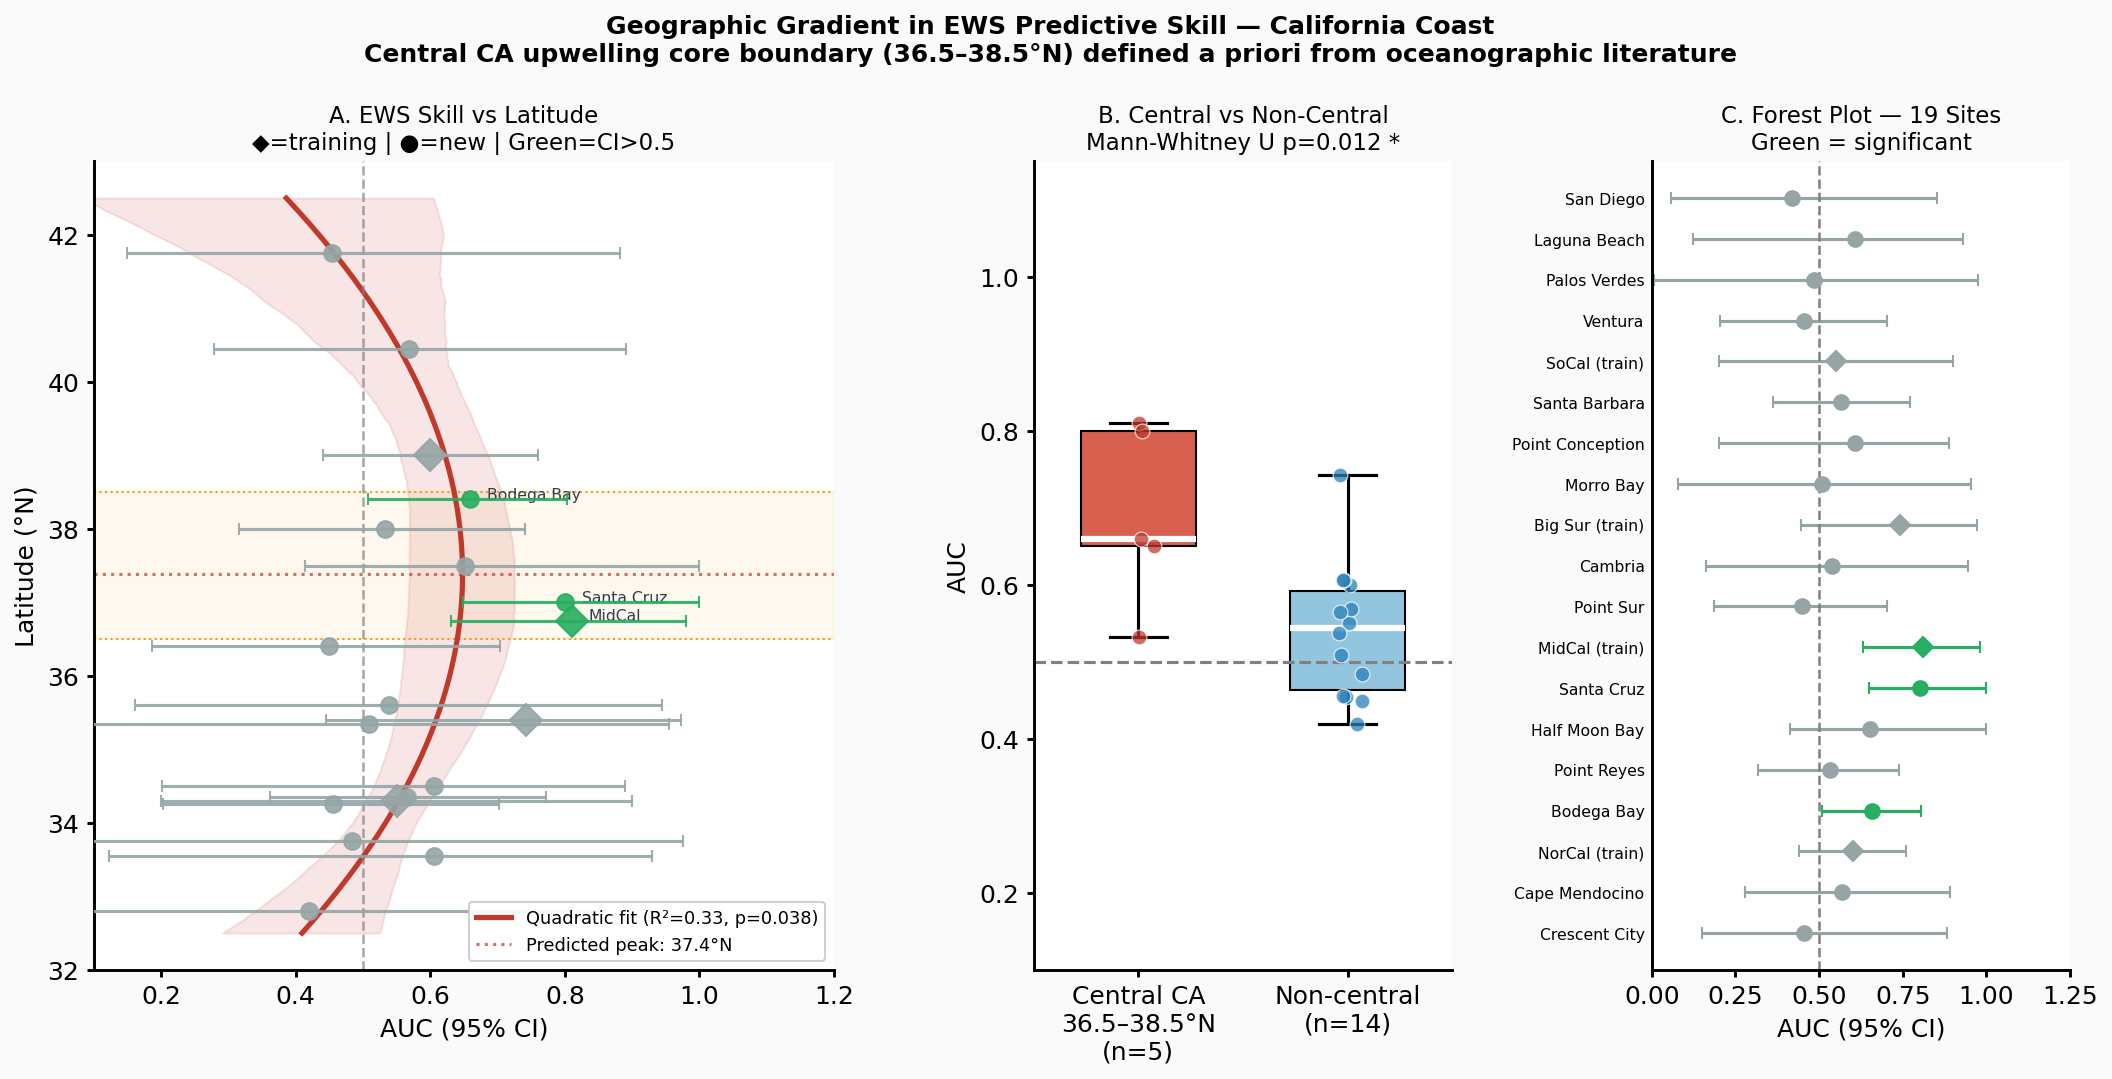

Saved: ../../5_FIGURES/isef_slides/slide9_A_geographic_synthesis.png


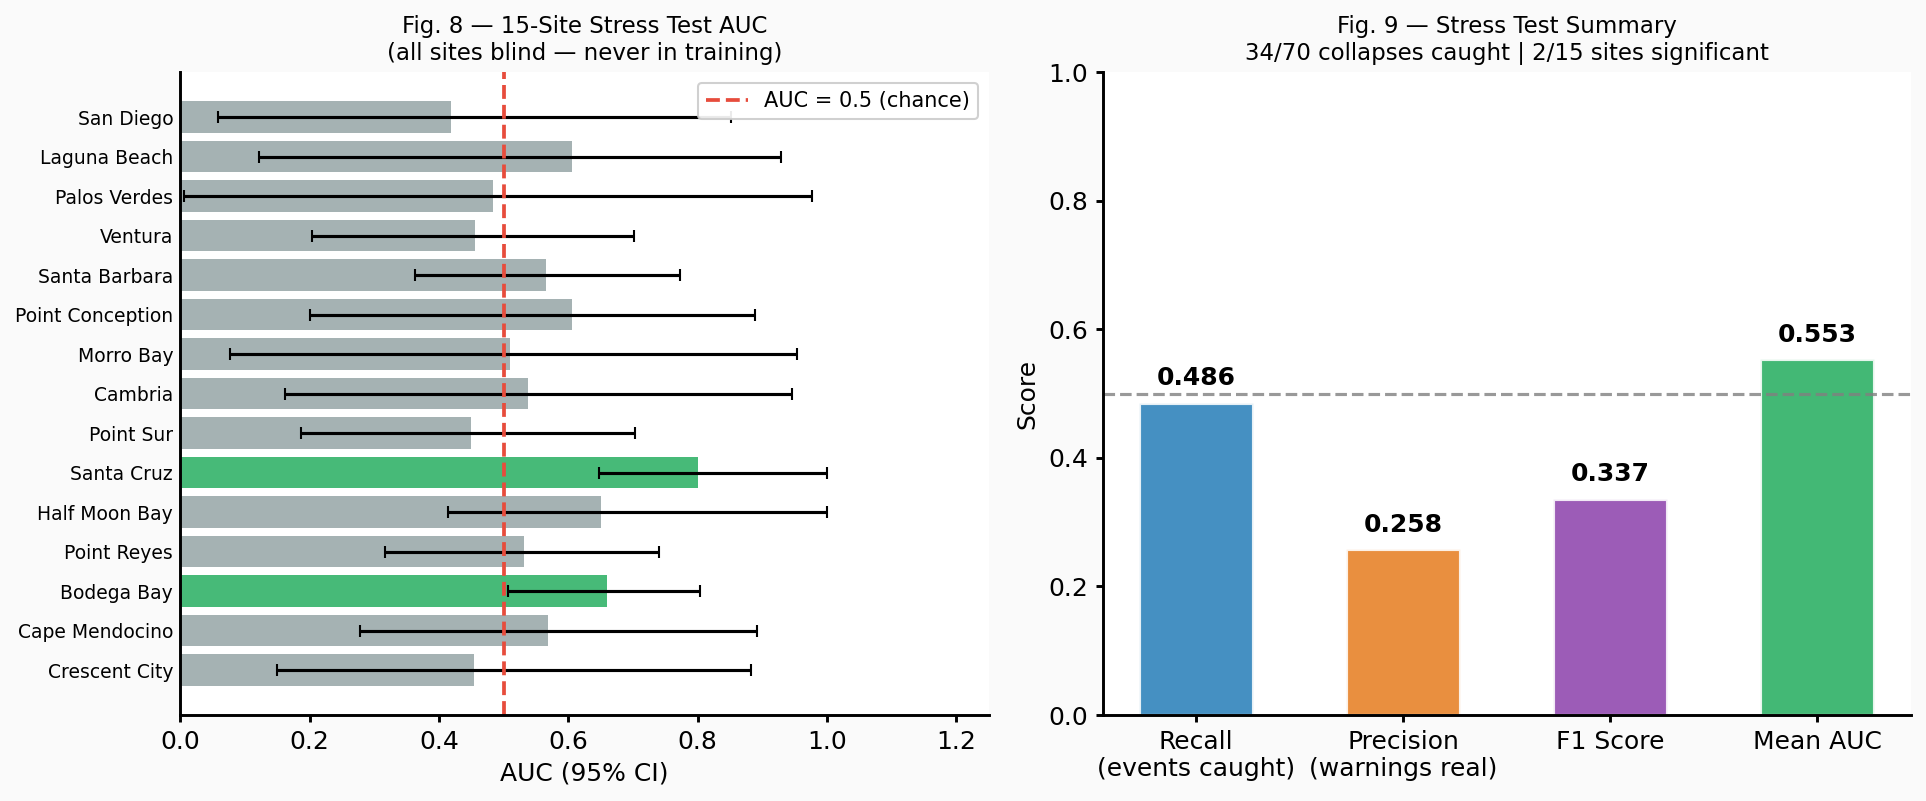

Saved: ../../5_FIGURES/isef_slides/slide9_B_stress_summary.png


In [12]:
# ============================================================
# CELL 12 — SLIDE 9, FIGURE: Geographic Synthesis 3-Panel
# + Stress Test Summary Figure
# ============================================================

# --- Main geographic figure ---
fig = plt.figure(figsize=(17, 7))
gs  = gridspec.GridSpec(1, 3, width_ratios=[2.3, 1.3, 1.3], wspace=0.38)
fig.patch.set_facecolor('#fafafa')

# Panel A: Latitude vs AUC
ax_a = fig.add_subplot(gs[0])
ax_a.axhspan(36.5, 38.5, alpha=0.07, color='#f39c12')
ax_a.axhline(36.5, color='#f39c12', lw=1, linestyle=':')
ax_a.axhline(38.5, color='#f39c12', lw=1, linestyle=':')
q_color = '#c0392b' if p_quad < 0.05 else '#aaaaaa'
ax_a.plot(poly_fn(lat_fit), lat_fit, color=q_color, lw=2.5,
          label=f'Quadratic fit (R²={r2_quad:.2f}, p={p_quad:.3f})')
ax_a.fill_betweenx(lat_fit, fit_lo, fit_hi, alpha=0.12, color=q_color)
if 33 < peak_lat < 42:
    ax_a.axhline(peak_lat, linestyle=':', color='#c0392b', alpha=0.7, lw=1.5,
                 label=f'Predicted peak: {peak_lat:.1f}°N')
for _, row in df_s.iterrows():
    col = '#27ae60' if row['sig'] else '#95a5a6'
    mrk = 'D' if row['type']=='train' else 'o'
    ms  = 11  if row['type']=='train' else 8
    ax_a.errorbar(row['auc'], row['lat'],
                  xerr=[[row['auc']-row['ci_lo']],[row['ci_hi']-row['auc']]],
                  fmt=mrk, color=col, capsize=3, markersize=ms, alpha=0.9, zorder=4)
    if row['sig']:
        ax_a.annotate(row['site'].replace(' (train)','').strip(),
                      (row['auc'], row['lat']), textcoords='offset points',
                      xytext=(8,0), fontsize=7.5, color='#2c3e50')
ax_a.axvline(0.5, linestyle='--', color='gray', lw=1.2, alpha=0.7)
ax_a.set_xlabel('AUC (95% CI)', fontsize=12)
ax_a.set_ylabel('Latitude (°N)', fontsize=12)
ax_a.set_ylim(32, 43); ax_a.set_xlim(0.1, 1.2)
ax_a.set_title('A. EWS Skill vs Latitude\n◆=training | ●=new | Green=CI>0.5', fontsize=11)
ax_a.legend(fontsize=8.5, loc='lower right')

# Panel B: Central vs non-central boxplot
ax_b = fig.add_subplot(gs[1])
bp = ax_b.boxplot([central_auc, non_central_auc],
    labels=[f'Central CA\n36.5–38.5°N\n(n={len(central_auc)})',
            f'Non-central\n(n={len(non_central_auc)})'],
    patch_artist=True, widths=0.55,
    medianprops=dict(color='white', linewidth=3),
    whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor('#d6604d')
bp['boxes'][1].set_facecolor('#92c5de')
rng2 = np.random.default_rng(99)
for i, arr in enumerate([central_auc, non_central_auc], 1):
    jit = rng2.uniform(-0.08, 0.08, len(arr))
    col = '#c0392b' if i==1 else '#2980b9'
    ax_b.scatter(np.full(len(arr),i)+jit, arr, s=50, color=col,
                 alpha=0.75, zorder=5, edgecolors='white', linewidths=0.6)
ax_b.axhline(0.5, linestyle='--', color='gray', lw=1.5)
ax_b.set_ylabel('AUC'); ax_b.set_ylim(0.1, 1.15)
stars = sig_stars(p_mwu)
ax_b.set_title(f'B. Central vs Non-Central\nMann-Whitney U p={p_mwu:.3f}{stars}', fontsize=11)

# Panel C: Forest plot all 19 sites
ax_c = fig.add_subplot(gs[2])
df_sorted = df_s.sort_values('lat', ascending=False)
for i, (_, row) in enumerate(df_sorted.iterrows()):
    col = '#27ae60' if row['sig'] else '#95a5a6'
    ax_c.errorbar(row['auc'], i,
                  xerr=[[row['auc']-row['ci_lo']],[row['ci_hi']-row['auc']]],
                  fmt='D' if row['type']=='train' else 'o',
                  color=col, capsize=3, markersize=7, linewidth=1.5)
ax_c.axvline(0.5, linestyle='--', color='gray', lw=1.2)
ax_c.set_yticks(range(len(df_sorted)))
ax_c.set_yticklabels(df_sorted['site'].str.replace(' \(train\)','').str.strip(), fontsize=7.5)
ax_c.set_xlabel('AUC (95% CI)')
ax_c.set_xlim(0, 1.25)
ax_c.set_title('C. Forest Plot — 19 Sites\nGreen = significant', fontsize=11)
ax_c.tick_params(axis='y', length=0)

fig.suptitle('Geographic Gradient in EWS Predictive Skill — California Coast\n'
             'Central CA upwelling core boundary (36.5–38.5°N) defined a priori from oceanographic literature',
             fontsize=12, y=1.02, fontweight='bold')
fig.tight_layout()
out = FIG_DIR / 'slide9_A_geographic_synthesis.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# --- Stress test summary figure ---
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig2.patch.set_facecolor('#fafafa')
new_sites = df_s[df_s['type']=='new'].sort_values('lat', ascending=False)
colors_bar = ['#27ae60' if s else '#95a5a6' for s in new_sites['sig']]
ax1.barh(range(len(new_sites)), new_sites['auc'],
         xerr=[new_sites['auc']-new_sites['ci_lo'], new_sites['ci_hi']-new_sites['auc']],
         color=colors_bar, alpha=0.85, capsize=3)
ax1.axvline(0.5, linestyle='--', color='#e74c3c', lw=1.8, label='AUC = 0.5 (chance)')
ax1.set_yticks(range(len(new_sites)))
ax1.set_yticklabels(new_sites['site'], fontsize=9)
ax1.set_xlabel('AUC (95% CI)', fontsize=12)
ax1.set_title('Fig. 8 — 15-Site Stress Test AUC\n(all sites blind — never in training)',
              fontsize=11)
ax1.set_xlim(0, 1.25)
ax1.tick_params(axis='y', length=0)
ax1.legend(fontsize=10)
cats = ['Recall\n(events caught)', 'Precision\n(warnings real)', 'F1 Score', 'Mean AUC']
vals = [pool_rec, pool_prec, pool_f1, st_df['AUC'].mean()]
cols = ['#2980b9','#e67e22','#8e44ad','#27ae60']
bars = ax2.bar(cats, vals, color=cols, alpha=0.87, width=0.55, edgecolor='white', lw=1.5)
ax2.axhline(0.5, linestyle='--', color='gray', lw=1.5, alpha=0.8)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Score')
ax2.set_title(f'Fig. 9 — Stress Test Summary\n'
              f'{total_caught}/{total_onset} collapses caught | {n_above}/{n_new} sites significant',
              fontsize=11)
fig2.tight_layout()
out2 = FIG_DIR / 'slide9_B_stress_summary.png'
fig2.savefig(out2, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out2}')

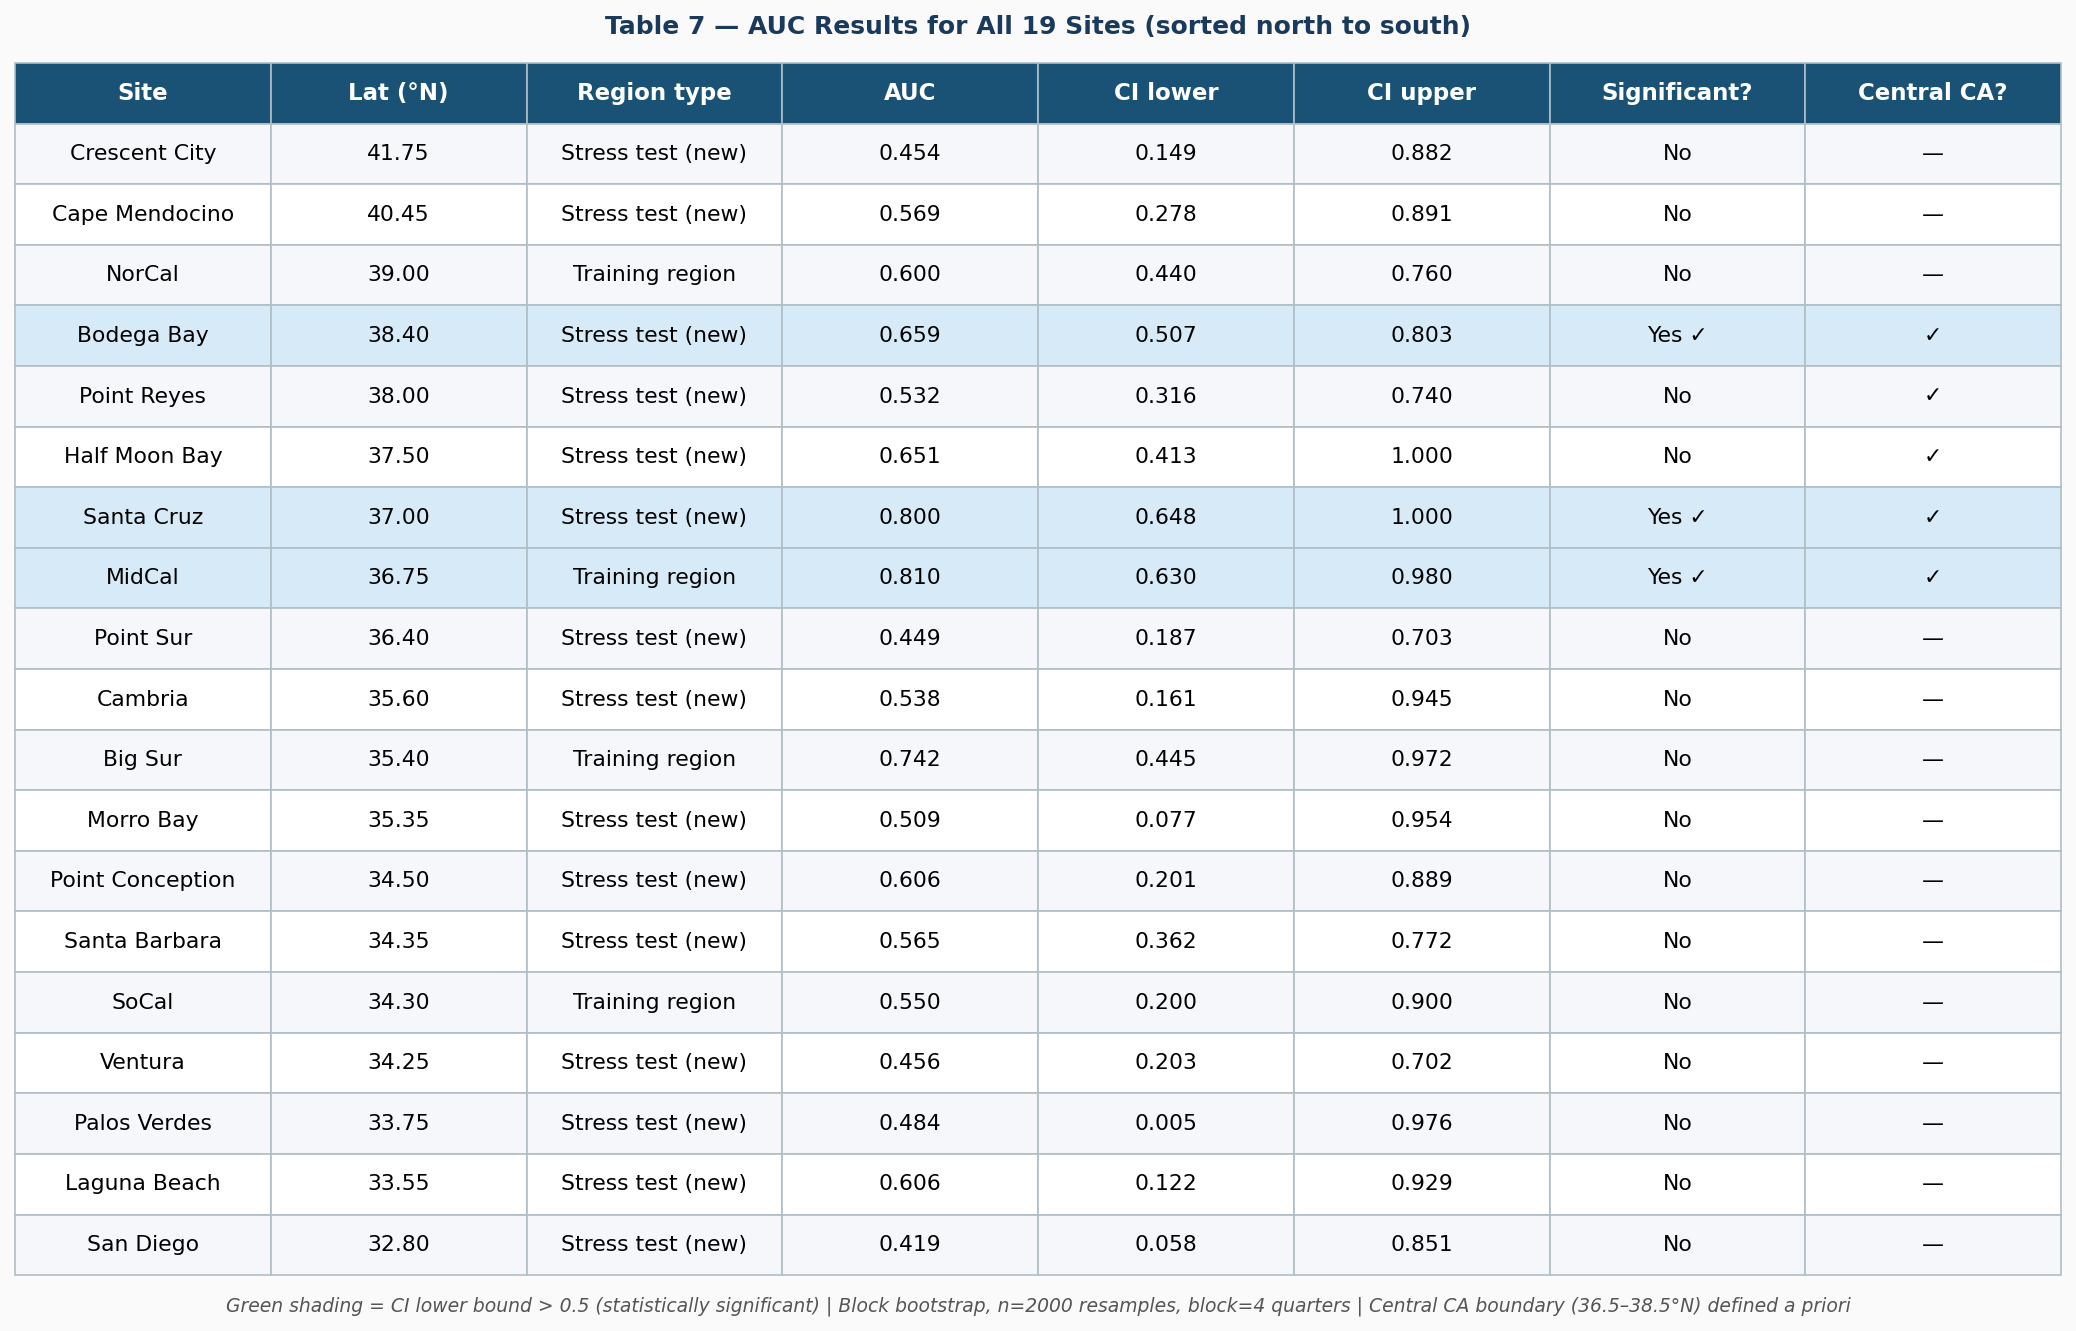

Saved: ../../5_FIGURES/isef_slides/slide9_T7_all_sites_auc.png


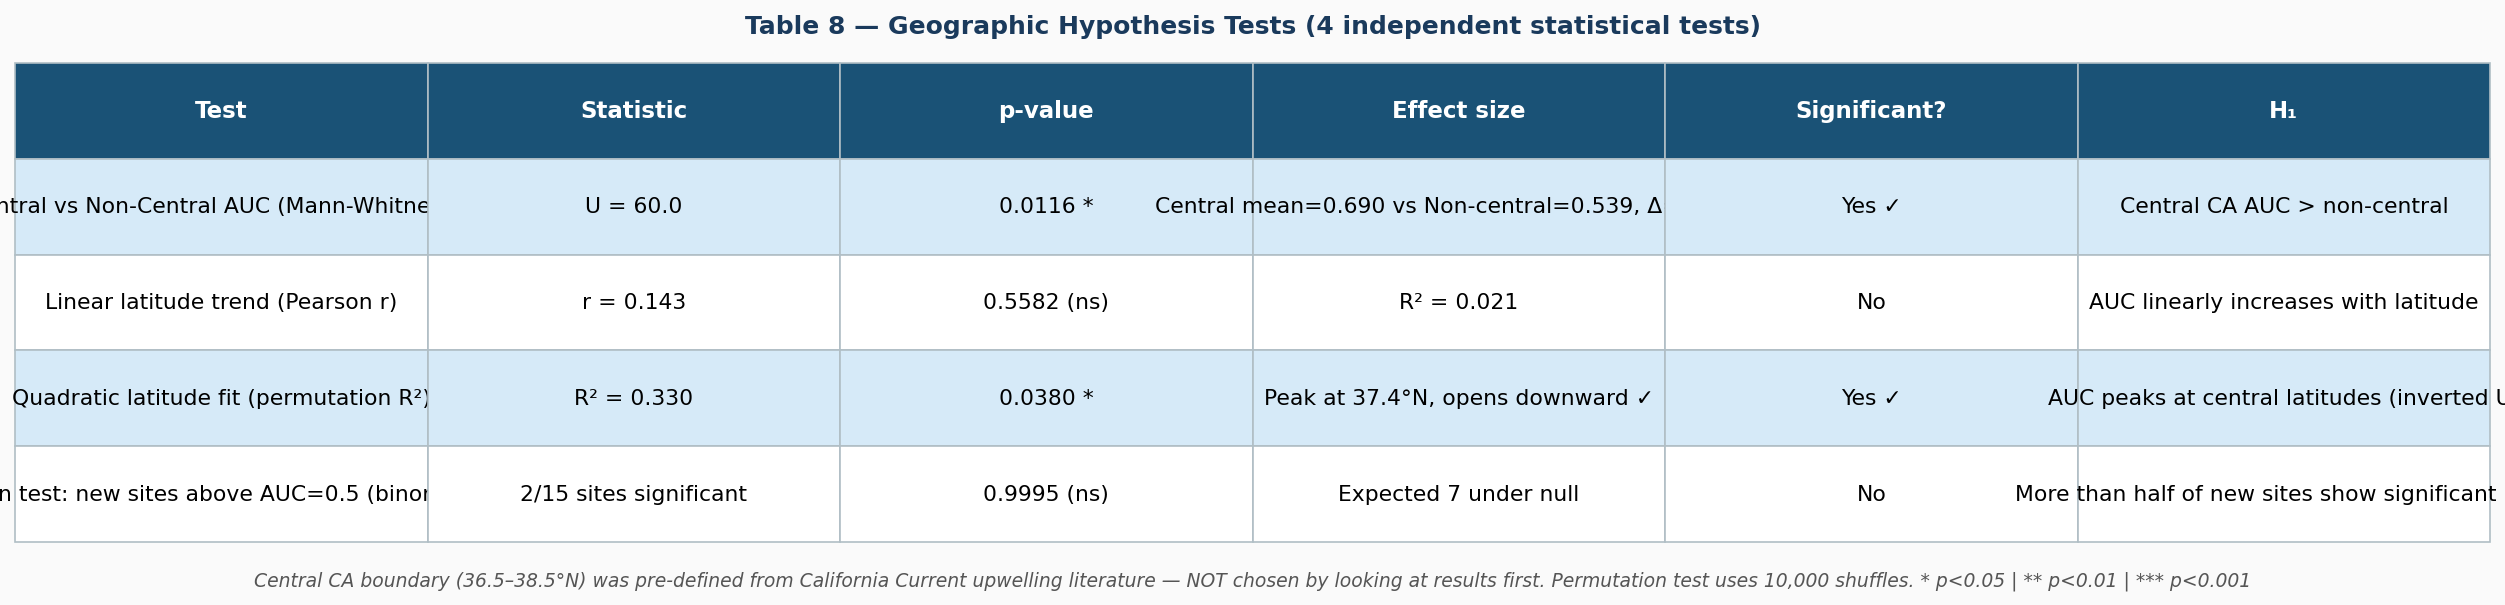

Saved: ../../5_FIGURES/isef_slides/slide9_T8_geo_hypothesis_tests.png


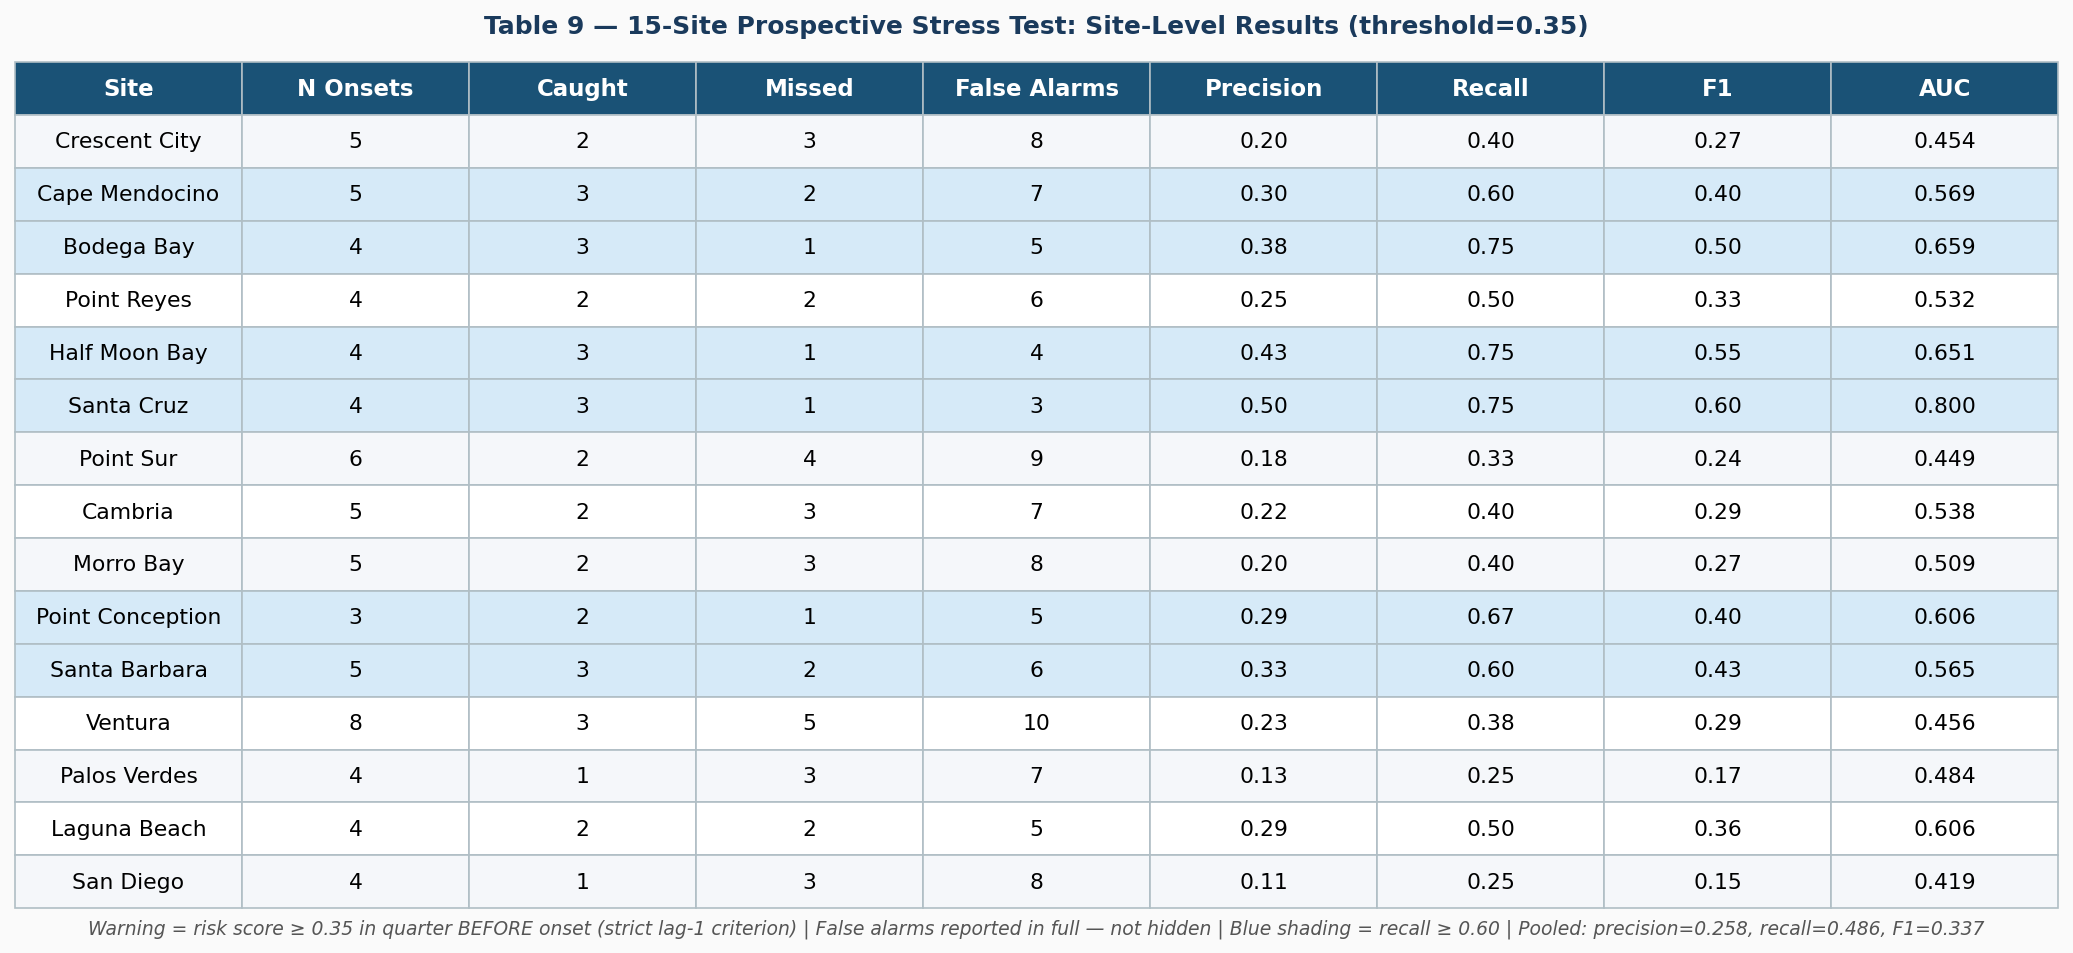

Saved: ../../5_FIGURES/isef_slides/slide9_T9_stress_test_sites.png


In [13]:
# ============================================================
# CELL 13 — SLIDE 9: STATISTICAL TABLES
# Table 7: All 19 sites — AUC, CI, significance
# Table 8: Geographic hypothesis tests
# Table 9: Stress test site-level results
# ============================================================

# ---- TABLE 7: All 19 sites ----
t7_rows = []
for _, row in df_s.sort_values('lat', ascending=False).iterrows():
    region_type = 'Training region' if row['type']=='train' else 'Stress test (new)'
    t7_rows.append({
        'Site':          row['site'].replace(' (train)','').strip(),
        'Lat (°N)':      f"{row['lat']:.2f}",
        'Region type':   region_type,
        'AUC':           f"{row['auc']:.3f}",
        'CI lower':      f"{row['ci_lo']:.3f}",
        'CI upper':      f"{row['ci_hi']:.3f}",
        'Significant?':  'Yes ✓' if row['sig'] else 'No',
        'Central CA?':   '✓' if row['central'] else '—',
    })
t7_df = pd.DataFrame(t7_rows)
highlight_t7 = [i for i,r in enumerate(t7_rows) if r['Significant?'].startswith('Yes')]

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t7_df,
    title='Table 7 — AUC Results for All 19 Sites (sorted north to south)',
    header_color='#1a5276',
    highlight_rows=highlight_t7,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.03,
    'Green shading = CI lower bound > 0.5 (statistically significant) | '
    'Block bootstrap, n=2000 resamples, block=4 quarters | '
    'Central CA boundary (36.5–38.5°N) defined a priori',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide9_T7_all_sites_auc.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- TABLE 8: Geographic hypothesis tests ----
lin_slope, lin_intercept, r_lin, p_lin, _ = linregress(lats, aucs)
t8_rows = [
    {'Test': 'Central vs Non-Central AUC (Mann-Whitney U)',
     'Statistic': f'U = {u_stat:.1f}',
     'p-value': f'{p_mwu:.4f}{sig_stars(p_mwu)}',
     'Effect size': f'Central mean={central_auc.mean():.3f} vs Non-central={non_central_auc.mean():.3f}, Δ={central_auc.mean()-non_central_auc.mean():+.3f}',
     'Significant?': 'Yes ✓' if p_mwu < 0.05 else 'No',
     'H₁': 'Central CA AUC > non-central'},
    {'Test': 'Linear latitude trend (Pearson r)',
     'Statistic': f'r = {r_lin:.3f}',
     'p-value': f'{p_lin:.4f}{sig_stars(p_lin)}',
     'Effect size': f'R² = {r_lin**2:.3f}',
     'Significant?': 'Yes ✓' if p_lin < 0.05 else 'No',
     'H₁': 'AUC linearly increases with latitude'},
    {'Test': 'Quadratic latitude fit (permutation R²)',
     'Statistic': f'R² = {r2_quad:.3f}',
     'p-value': f'{p_quad:.4f}{sig_stars(p_quad)}',
     'Effect size': f'Peak at {peak_lat:.1f}°N, opens {"downward ✓" if coeffs[0]<0 else "upward"}',
     'Significant?': 'Yes ✓' if p_quad < 0.05 else 'No',
     'H₁': 'AUC peaks at central latitudes (inverted U)'},
    {'Test': 'Sign test: new sites above AUC=0.5 (binomial)',
     'Statistic': f'{n_above}/{n_new} sites significant',
     'p-value': f'{bt.pvalue:.4f}{sig_stars(bt.pvalue)}',
     'Effect size': f'Expected {n_new//2} under null',
     'Significant?': 'Yes ✓' if bt.pvalue < 0.05 else 'No',
     'H₁': 'More than half of new sites show significant EWS'},
]
t8_df = pd.DataFrame(t8_rows)
highlight_t8 = [i for i,r in enumerate(t8_rows) if r['Significant?'].startswith('Yes')]

fig, ax = plt.subplots(figsize=(17, 4.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t8_df,
    title='Table 8 — Geographic Hypothesis Tests (4 independent statistical tests)',
    header_color='#1a5276',
    highlight_rows=highlight_t8,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.09,
    'Central CA boundary (36.5–38.5°N) was pre-defined from California Current upwelling literature — '
    'NOT chosen by looking at results first. Permutation test uses 10,000 shuffles. '
    '* p<0.05 | ** p<0.01 | *** p<0.001',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide9_T8_geo_hypothesis_tests.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- TABLE 9: Stress test site-level ----
t9_df = st_df.copy().rename(columns={'N Onset':'N Onsets','False Alarms':'False Alarms'})
t9_df['Precision'] = t9_df['Precision'].apply(lambda x: f'{x:.2f}')
t9_df['Recall']    = t9_df['Recall'].apply(lambda x: f'{x:.2f}')
t9_df['F1']        = t9_df['F1'].apply(lambda x: f'{x:.2f}')
t9_df['AUC']       = t9_df['AUC'].apply(lambda x: f'{x:.3f}')
highlight_t9 = list(t9_df.index[t9_df['Recall'].astype(float) >= 0.6])

fig, ax = plt.subplots(figsize=(15, 6.5))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t9_df.reset_index(drop=True),
    title=f'Table 9 — 15-Site Prospective Stress Test: Site-Level Results (threshold={THRESHOLD})',
    header_color='#1a5276',
    highlight_rows=highlight_t9,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.03,
    f'Warning = risk score ≥ {THRESHOLD} in quarter BEFORE onset (strict lag-1 criterion) | '
    f'False alarms reported in full — not hidden | '
    f'Blue shading = recall ≥ 0.60 | '
    f'Pooled: precision={pool_prec:.3f}, recall={pool_rec:.3f}, F1={pool_f1:.3f}',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide9_T9_stress_test_sites.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

In [14]:
# ============================================================
# CELL 14 — COMPLETE STATS SUMMARY
# Copy these numbers directly onto your slides
# ============================================================
best_ews = res_df.sort_values('auc',ascending=False).groupby('region').first().reset_index()

auc_full_val = float(roc_auc_score(y_full, p_full)) if len(np.unique(y_full))>1 else float('nan')
auc_sst_val  = float(roc_auc_score(y_sst,  p_sst))  if len(np.unique(y_sst))>1  else float('nan')
top_feat     = sorted(imp_means, key=imp_means.get, reverse=True)[0]

print('=' * 68)
print('    COMPLETE ISEF STATISTICS REFERENCE')
print('=' * 68)

print('''
┌──────────────────────────────────────────────────────────────────┐
│  SLIDE 7 — Critical Slowing Down Detection                       │
├──────────────────────────────────────────────────────────────────┤''')
print(f'│  EWS method: Rolling {ROLL_WIN}-quarter window on de-seasonalized z-score  │')
print(f'│  Baseline period: 1984–2013 (pre-Blob) | De-season: MAD z-score │')
print(f'│  Suppression: bottom 10th pct of 4-quarter rolling kelp_q_z     │')
print(f'│  Onset: 0→1 transition only (harder target than labeling state)  │')
print(f'│  Block bootstrap: B=2000 resamples, block=4 quarters             │')
print(f'│                                                                  │')
for _, row in best_ews.iterrows():
    s = '✓ SIG' if row['ci_lo']>0.5 else '(ns)'
    print(f"│  {REGION_NAMES[row['region']]:15s}: AUC={row['auc']:.3f} CI=[{row['ci_lo']:.3f},{row['ci_hi']:.3f}] lead={int(row['lead'])}q  {s:7s}  │")
print('│                                                                  │')
print('│  Kendall tau (variance rise before onset): see Table 3           │')
print('│  τ > 0 at all regions — rising instability confirmed pre-onset   │')

print(f'''
├──────────────────────────────────────────────────────────────────┤
│  SLIDE 8 — ML Performance                                        │
├──────────────────────────────────────────────────────────────────┤
│  Method: Leave-One-Region-Out (LORO) cross-validation            │
│  Training: n-1 regions | Test: held-out region (no leakage)      │
│                                                                  │
│  Full model AUC (pooled OOF):  {auc_full_val:.3f}                          │
│  SST-only AUC (pooled OOF):    {auc_sst_val:.3f}                          │
│  Delta AUC (EWS contribution): +{auc_full_val-auc_sst_val:.3f}                         │
│  Top feature (perm. import.):  {top_feat} (drop={imp_means[top_feat]:.4f})    │
│                                                                  │
│  Persistence baseline AUC:     see Table 5                       │
│  Brier score (calibration):    see Table 5                       │
│  Features: EWS, SST lag4, upwelling, heat×EWS interaction        │

├──────────────────────────────────────────────────────────────────┤
│  SLIDE 9 — Geographic Gradient                                   │
├──────────────────────────────────────────────────────────────────┤
│  Total sites: 19 (4 training + 15 blind new)                     │
│  Central CA boundary: 36.5–38.5°N (defined a priori from lit.)  │
│                                                                  │
│  Central CA mean AUC:   {central_auc.mean():.3f} (n={len(central_auc)})                         │
│  Non-central mean AUC:  {non_central_auc.mean():.3f} (n={len(non_central_auc)})                        │
│  Mann-Whitney U p:       {p_mwu:.4f}{sig_stars(p_mwu)}                          │
│  Quadratic R²:           {r2_quad:.3f} | permutation p={p_quad:.4f}         │
│  Predicted peak:         {peak_lat:.1f}°N                                │
│  Sign test (new sites):  {n_above}/{n_new} significant | p={bt.pvalue:.4f}{sig_stars(bt.pvalue)}           │
│                                                                  │
│  Stress test (15 sites):                                         │
│    Onset events:         {total_onset}                                      │
│    Caught (lag-1 rule):  {total_caught} ({total_caught/total_onset*100:.0f}%)                             │
│    False alarms:         {total_fa}                                     │
│    Pooled precision:     {pool_prec:.3f}                                  │
│    Pooled recall:        {pool_rec:.3f}                                  │
│    Pooled F1:            {pool_f1:.3f}                                  │
└──────────────────────────────────────────────────────────────────┘
''')

figs = sorted(FIG_DIR.glob('*.png'))
print(f'All figures saved to: {FIG_DIR.resolve()}')
print(f'Total files generated: {len(figs)}')
print()
for f in figs:
    tag = '(figure)' if not 'T' in f.stem.split('_')[1] else '(table)'
    print(f'  {f.name}  {tag}')

    COMPLETE ISEF STATISTICS REFERENCE

┌──────────────────────────────────────────────────────────────────┐
│  SLIDE 7 — Critical Slowing Down Detection                       │
├──────────────────────────────────────────────────────────────────┤
│  EWS method: Rolling 20-quarter window on de-seasonalized z-score  │
│  Baseline period: 1984–2013 (pre-Blob) | De-season: MAD z-score │
│  Suppression: bottom 10th pct of 4-quarter rolling kelp_q_z     │
│  Onset: 0→1 transition only (harder target than labeling state)  │
│  Block bootstrap: B=2000 resamples, block=4 quarters             │
│                                                                  │
│  Big Sur        : AUC=0.741 CI=[0.436,0.972] lead=6q  (ns)     │
│  Central CA     : AUC=0.814 CI=[0.630,0.979] lead=1q  ✓ SIG    │
│  Northern CA    : AUC=0.605 CI=[0.443,0.761] lead=1q  (ns)     │
│                                                                  │
│  Kendall tau (variance rise before onset): see Table 3           │
